# EDA - Exploratory Data Analysis



## Importar Librerías

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la evaluación estadística, la visualización, la transformación de datos, la fusión y la unión.

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

---

Se Instala el paquete `ucimlrepo` desde PyPI (Python Package Index).  
Este paquete permite acceder a datasets del repositorio UCI Machine Learning.

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


## Lectura de Datos

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.  
`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# metadata 
print(cdc_diabetes_health_indicators.metadata)

# Se X e y (ambos son DataFrames)
df = pd.concat([X, y], axis=1) 


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

---

Se muestran las primeras filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [4]:
print(df.head().to_string())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
0       1         1          1   40       1       0                     0             0       0        1                  0              1            0        5        18        15         1    0    9          4       3                0
1       0         0          0   25       1       0                     0             1       0        0                  0              0            1        3         0         0         0    0    7          6       1                0
2       1         1          1   28       0       0                     0             0       1        0                  0              1            1        5        30        30         1    0    9          4       8                0
3       1         0          1   27       0       0 

---

Se muestran las últimas filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [5]:
print(df.tail().to_string())

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
253675       1         1          1   45       0       0                     0             0       1        1                  0              1            0        3         0         5         0    1    5          6       7                0
253676       1         1          1   18       0       0                     0             0       0        0                  0              1            0        4         0         0         1    0   11          2       4                1
253677       0         0          1   28       0       0                     0             1       1        0                  0              1            0        1         0         0         0    0    2          5       2                0
253678       1         0        

---

Se presenta un resumen detallado de todas las variables del dataset, incluyendo su rol (predictora o objetivo), el tipo de dato (numérico, categórico, binario) y la identificación de valores faltantes, lo que permite evaluar la integridad y estructura de los datos para su posterior procesamiento.

In [6]:
print(cdc_diabetes_health_indicators.variables) 

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

**Interpretación del Dataset:**

Este conjunto de datos contiene información relacionada con factores de salud y demográficos asociados a la diabetes. La variable objetivo (`Diabetes_binary`) indica si un paciente tiene diabetes o prediabetes (1) o no (0). Entre las características destacan variables binarias como `HighBP` (hipertensión), `HighChol` (colesterol alto) y `Smoker` (fumador), que representan condiciones médicas o hábitos relevantes. También se incluyen variables numéricas como `BMI` (índice de masa corporal) y escalas de salud general (`GenHlth`, `MentHlth`, `PhysHlth`), que miden percepciones y estados de salud física y mental. Además, hay atributos demográficos como `Sex` (sexo), `Age` (edad), `Education` (nivel educativo) e `Income` (ingresos), que permiten analizar patrones según grupos poblacionales. La ausencia de valores faltantes facilita el análisis, y las descripciones detalladas de cada campo ayudan a contextualizar su relevancia clínica. 

---

Se calcula el número de valores únicos para cada variable del DataFrame.

In [7]:
df.nunique()

HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
Diabetes_binary          2
dtype: int64

**Interpretación del Conteo de Valores Únicos:**

El análisis de valores únicos revela una estructura clara y consistente con la naturaleza de las variables descritas. Las variables binarias muestran exactamente 2 valores únicos (0 y 1), confirmando su correcta codificación como indicadores binarios de presencia/ausencia de condiciones médicas, hábitos o características demográficas. Las variables numéricas muestran mayor dispersión: `BMI` presenta 84 valores únicos, reflejando la diversidad esperada en índices de masa corporal, mientras que `MentHlth` y `PhysHlth` muestran 31 valores cada una (correspondiendo a los posibles días de afectación de salud en un mes). Estos resultados validan la integridad del conjunto de datos y confirman que todas las variables mantienen los rangos y categorías esperados según su descripción.

## Análisis Univariado

### Variables Binarias

Se identifican y analizan las variables binarias (aquellas con solo 2 valores únicos) en el DataFrame.  
Mostrando: 
1. Conteo absoluto de ocurrencias para cada valor (0 y 1).  
2. Porcentaje respecto al total (redondeado a 1 decimal).

In [8]:
# Filtrar variables binarias 
binarias = [col for col in df.columns if df[col].nunique() == 2]

# Calcular proporciones y crear DataFrame
data = {
    col: [
        f"{df[col].value_counts().get(0, 0)} ({round(df[col].value_counts(normalize=True).get(0, 0)*100, 1)}%)",  # No (0)
        f"{df[col].value_counts().get(1, 0)} ({round(df[col].value_counts(normalize=True).get(1, 0)*100, 1)}%)"   # Sí (1)
    ] for col in binarias
}

tabla_porcentajes = pd.DataFrame(data, index=['No (0)', 'Si (1)'])

display(tabla_porcentajes)  

,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Diabetes_binary
No (0),144851 (57.1%),146089 (57.6%),9470 (3.7%),141257 (55.7%),243388 (95.9%),229787 (90.6%),61760 (24.3%),92782 (36.6%),47839 (18.9%),239424 (94.4%),12417 (4.9%),232326 (91.6%),211005 (83.2%),141974 (56.0%),218334 (86.1%)
Si (1),108829 (42.9%),107591 (42.4%),244210 (96.3%),112423 (44.3%),10292 (4.1%),23893 (9.4%),191920 (75.7%),160898 (63.4%),205841 (81.1%),14256 (5.6%),241263 (95.1%),21354 (8.4%),42675 (16.8%),111706 (44.0%),35346 (13.9%)


---

Se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:
1. Gráfico de Barras:  
- Muestra el conteo absoluto de cada categoría (0 y 1).  
- Ideal para comparar magnitudes visualmente.
    
2. Gráfico de Torta:  
- Muestra la proporción porcentual de cada categoría.  
- Útil para entender el balance/imbalance entre clases.

Column: HighBP


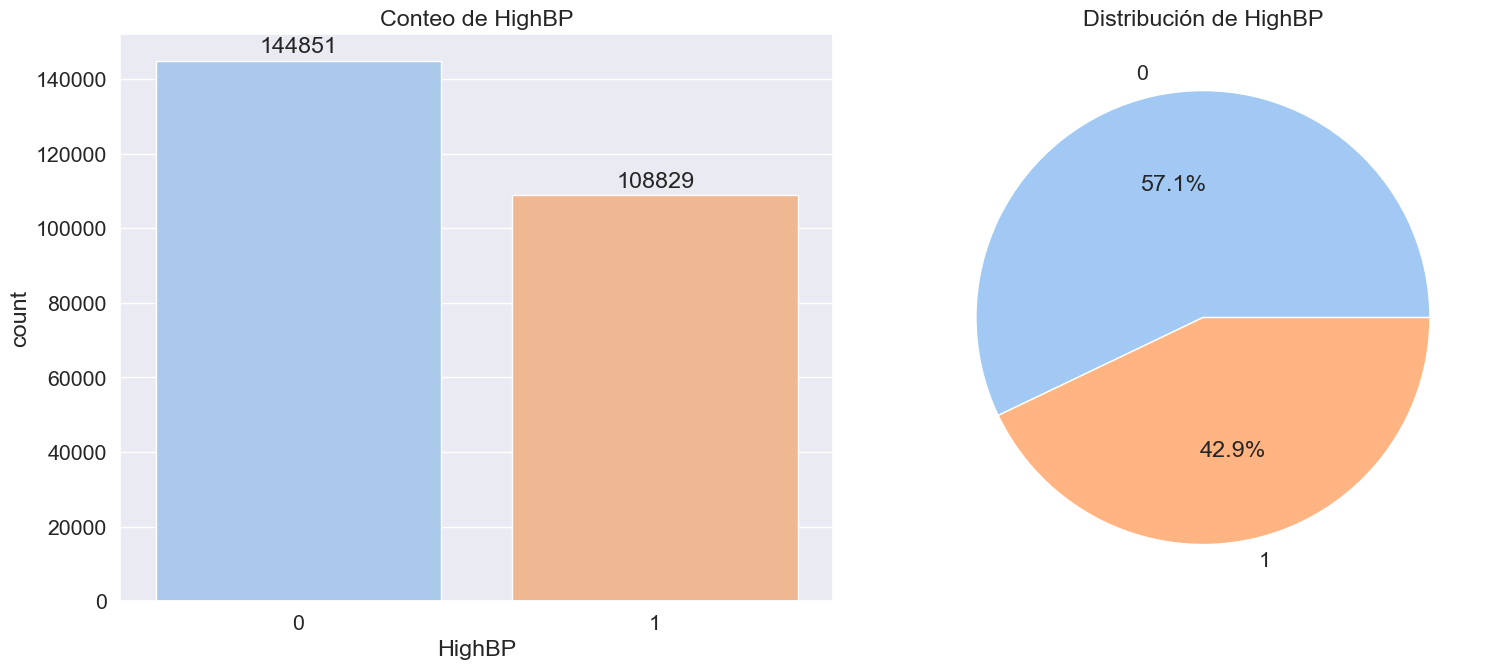

Column: HighChol


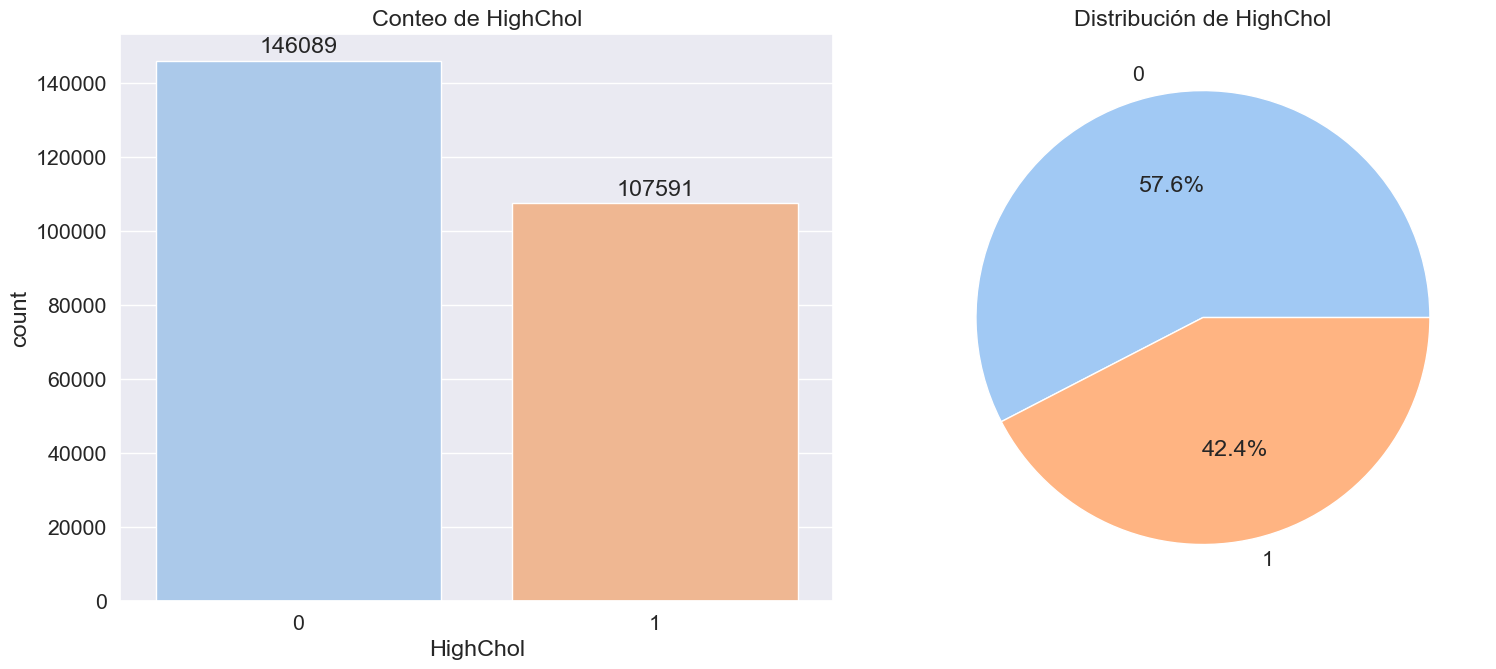

Column: CholCheck


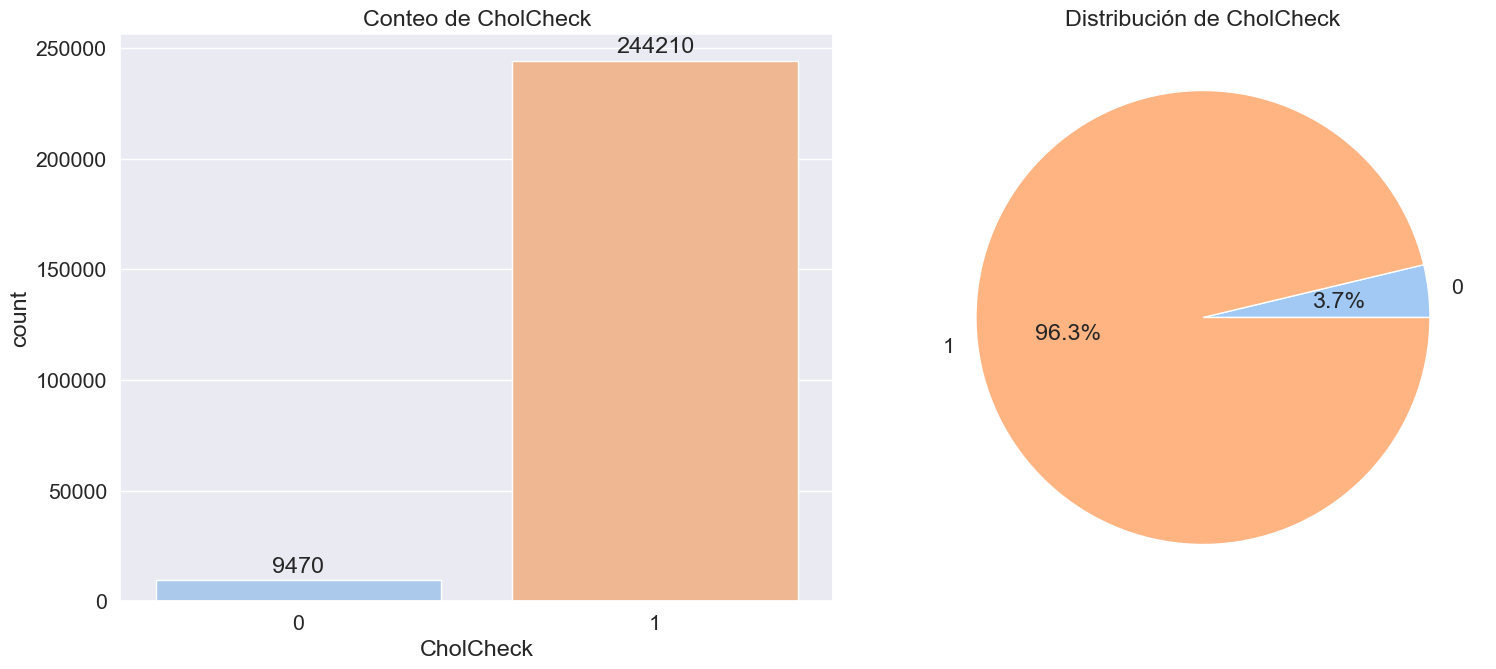

Column: Smoker


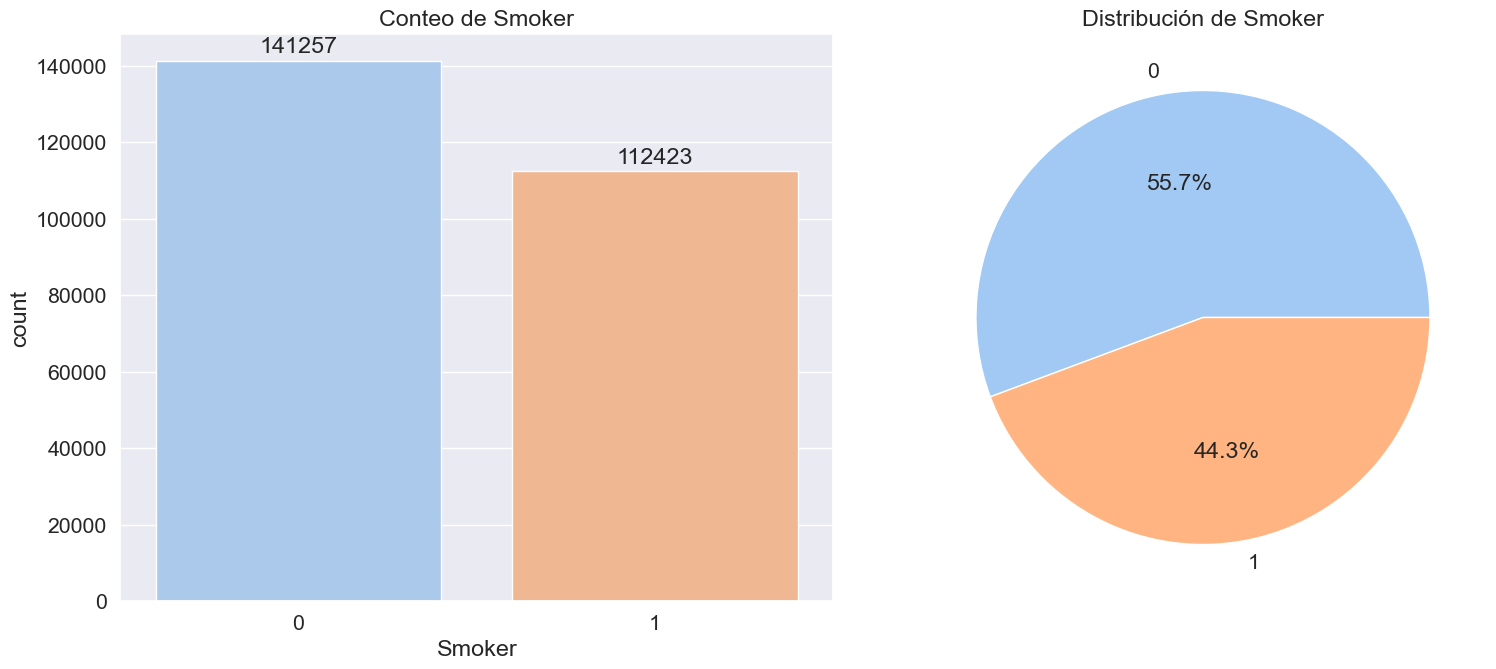

Column: Stroke


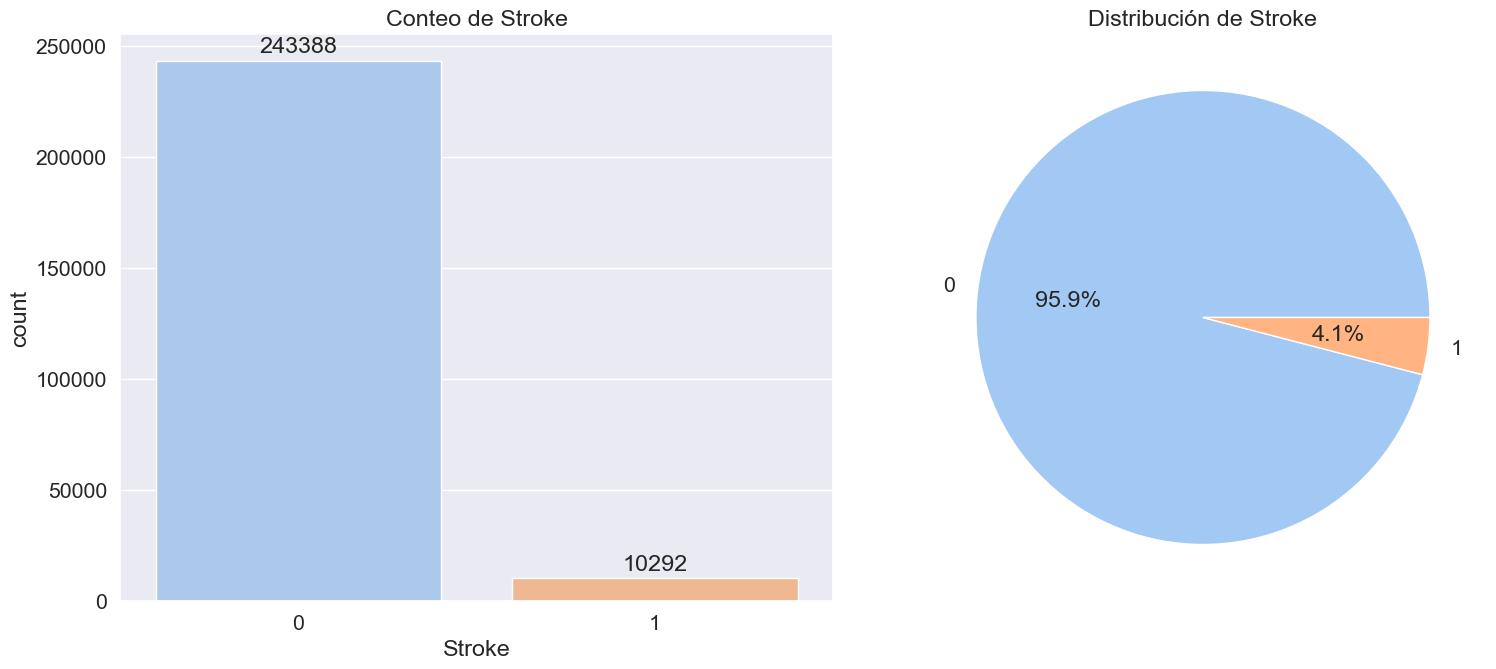

Column: HeartDiseaseorAttack


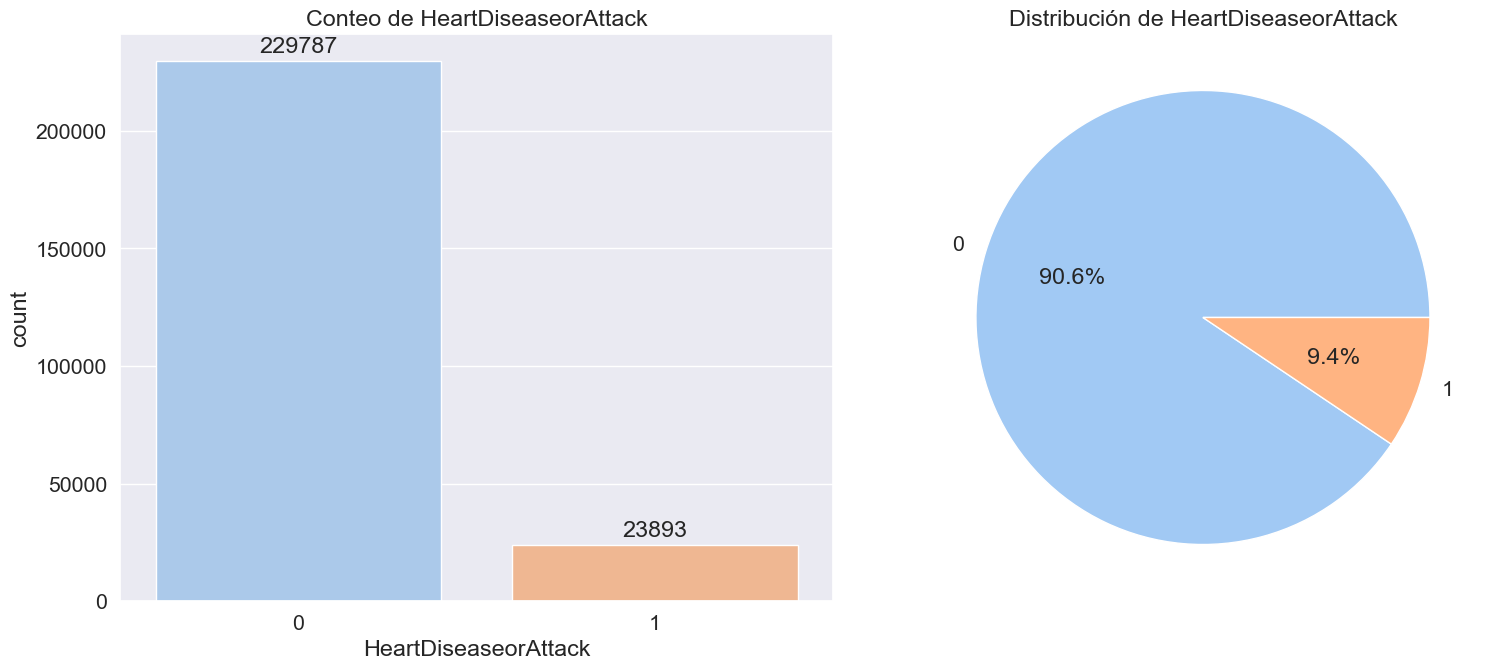

Column: PhysActivity


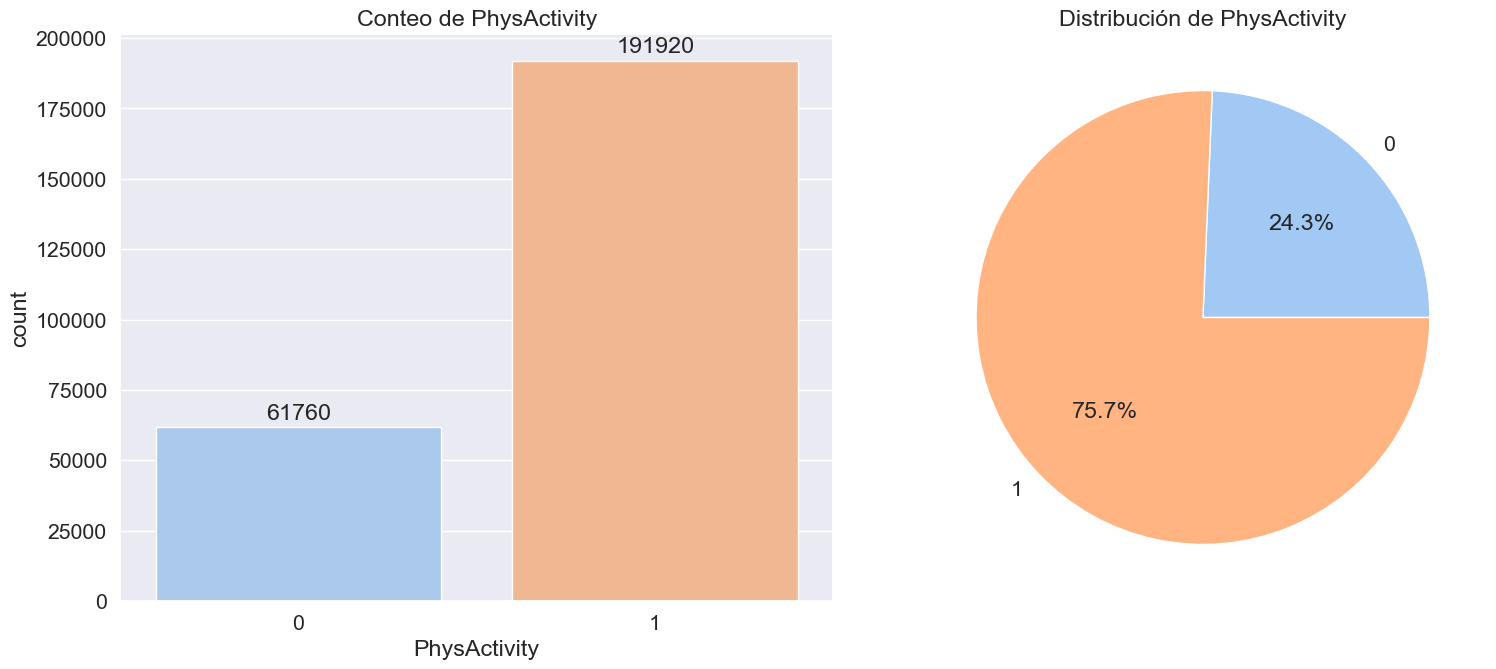

Column: Fruits


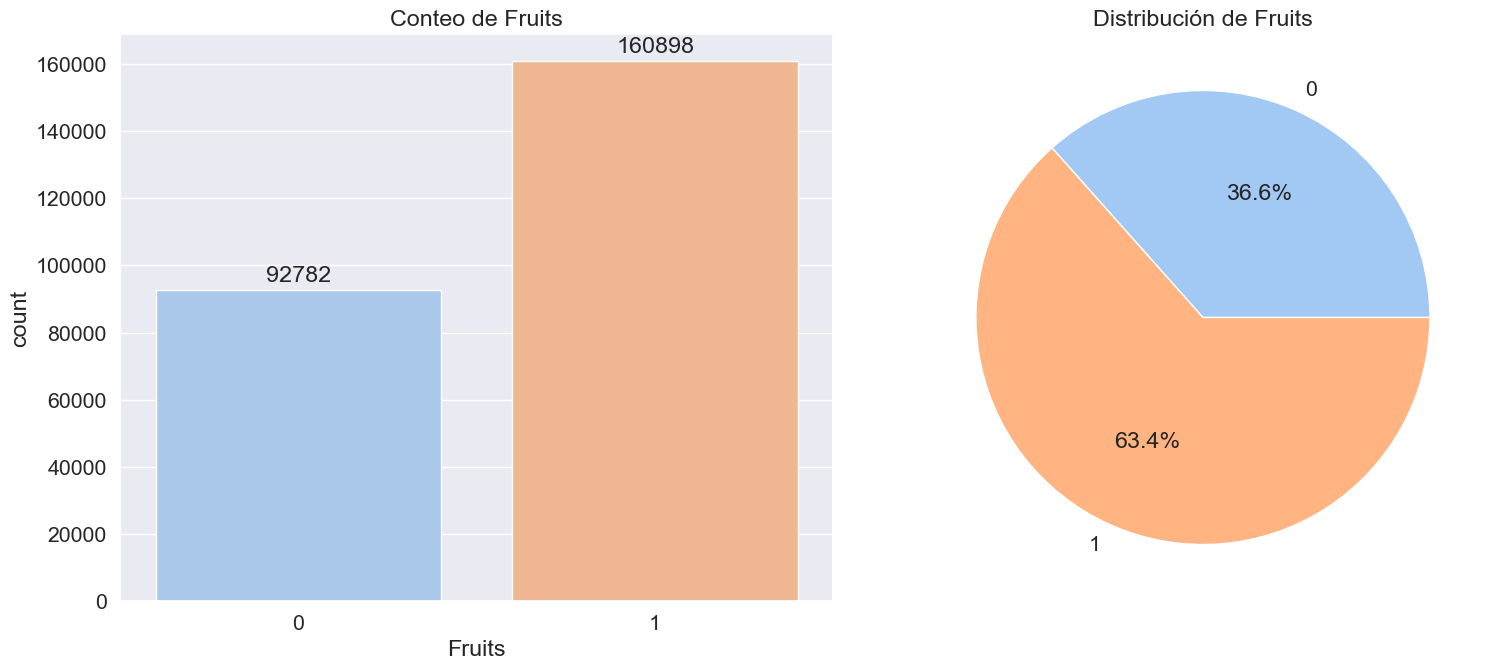

Column: Veggies


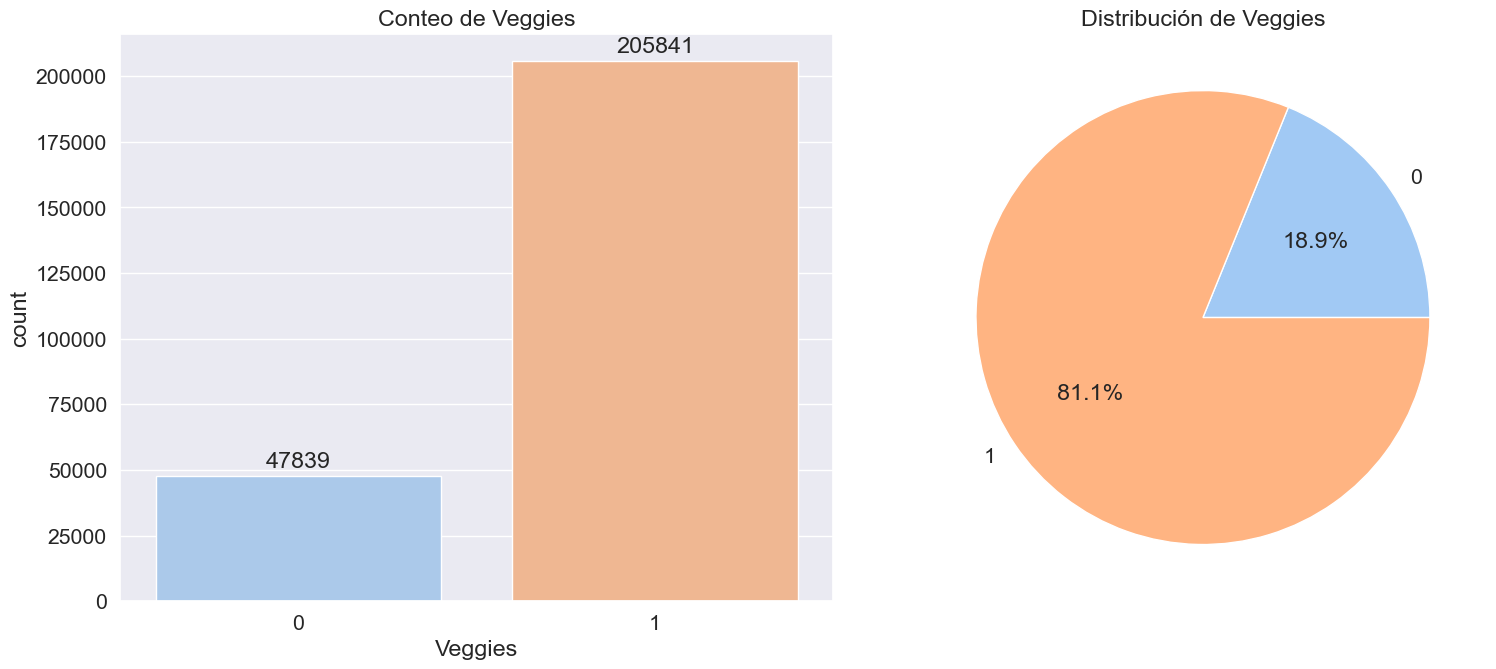

Column: HvyAlcoholConsump


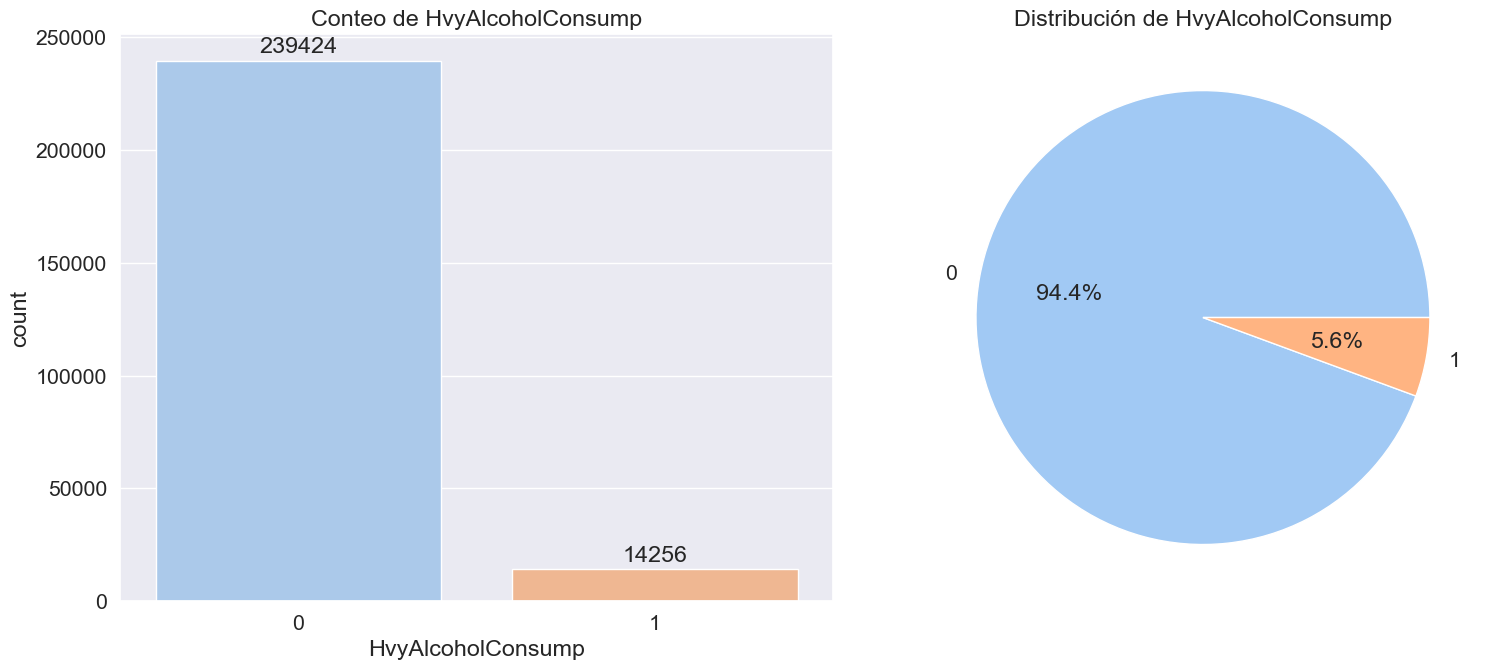

Column: AnyHealthcare


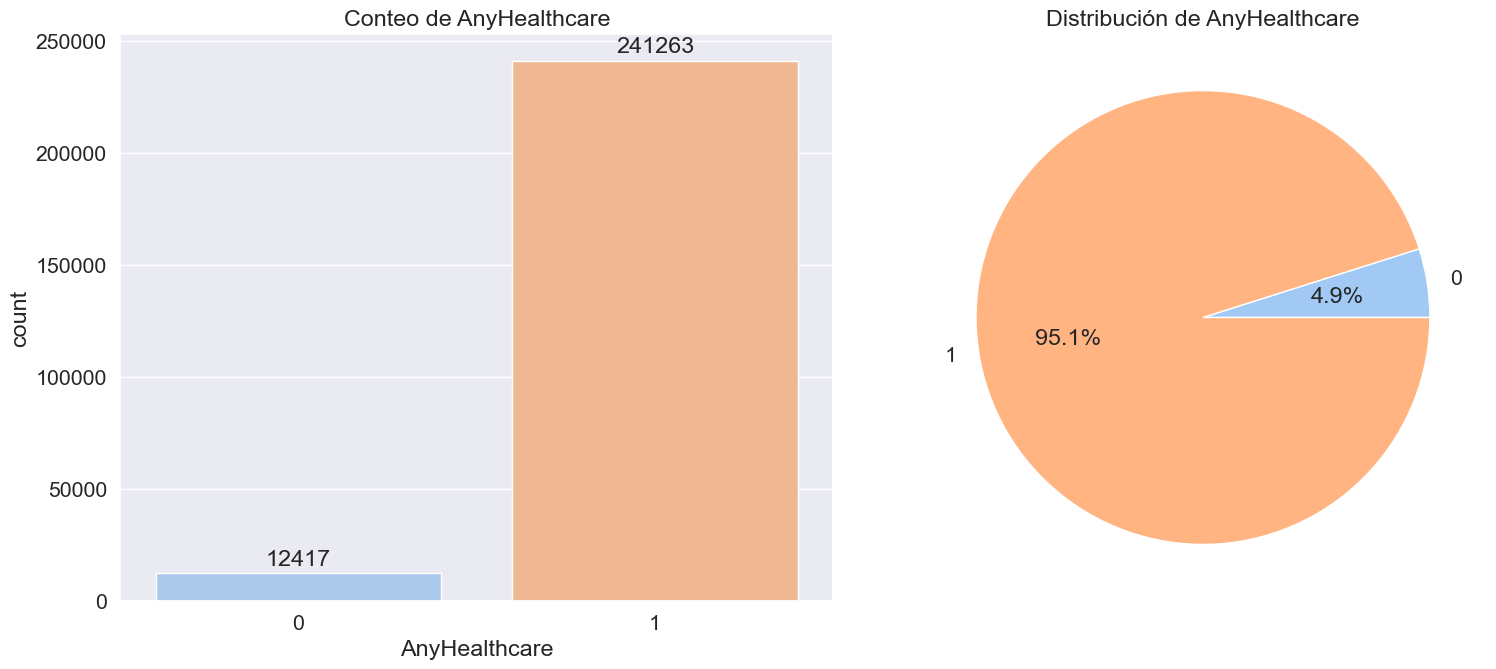

Column: NoDocbcCost


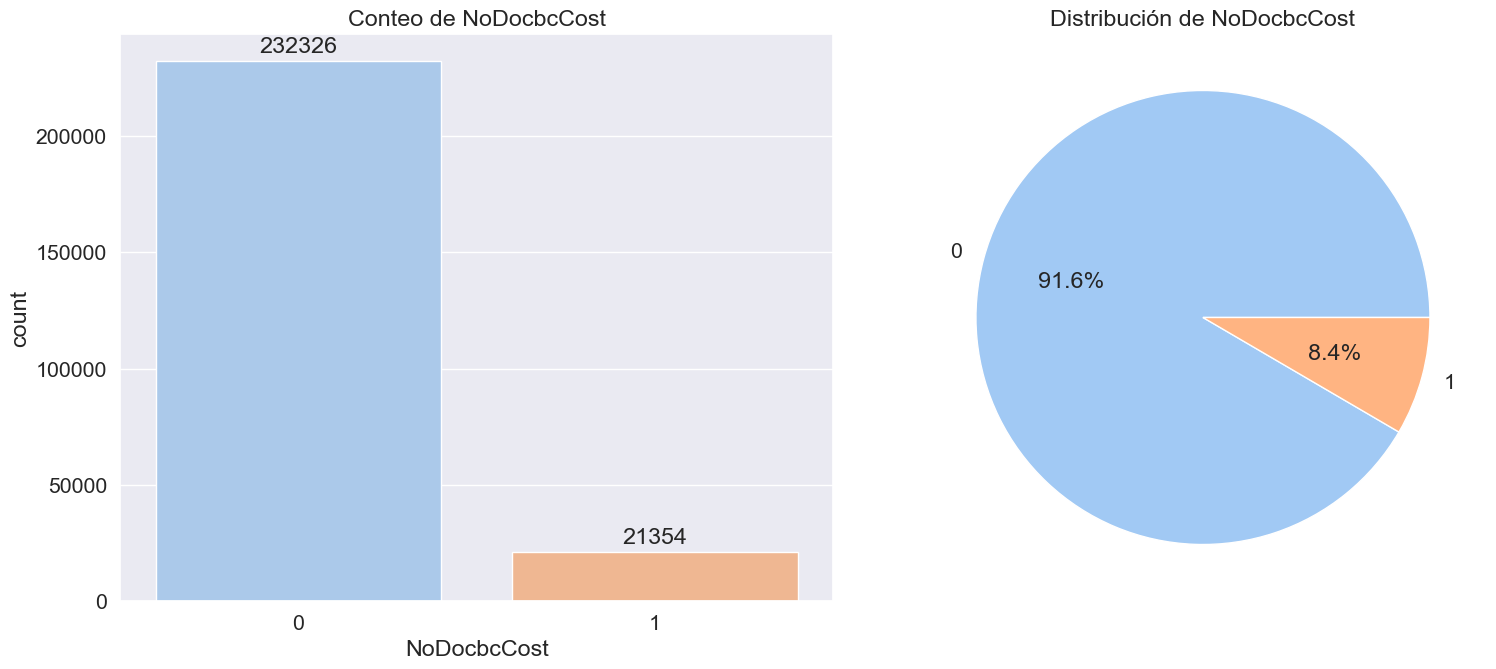

Column: DiffWalk


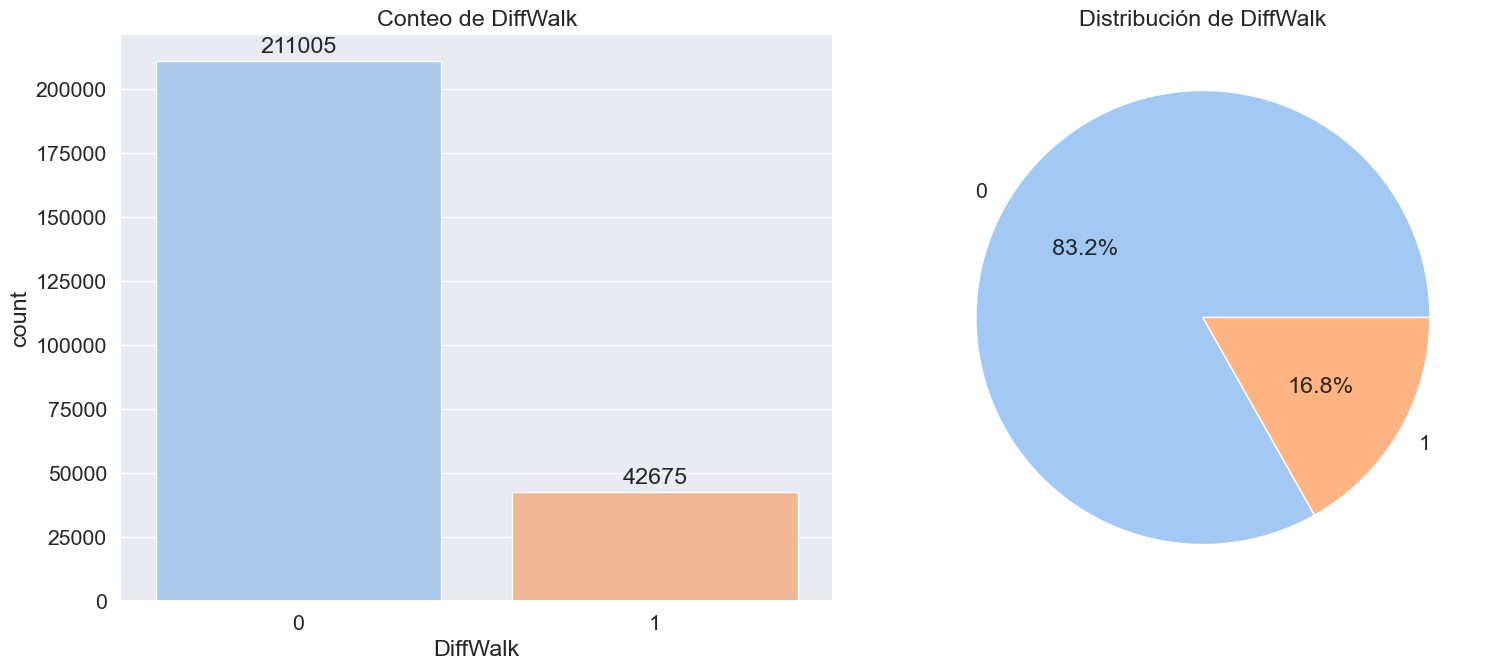

Column: Sex


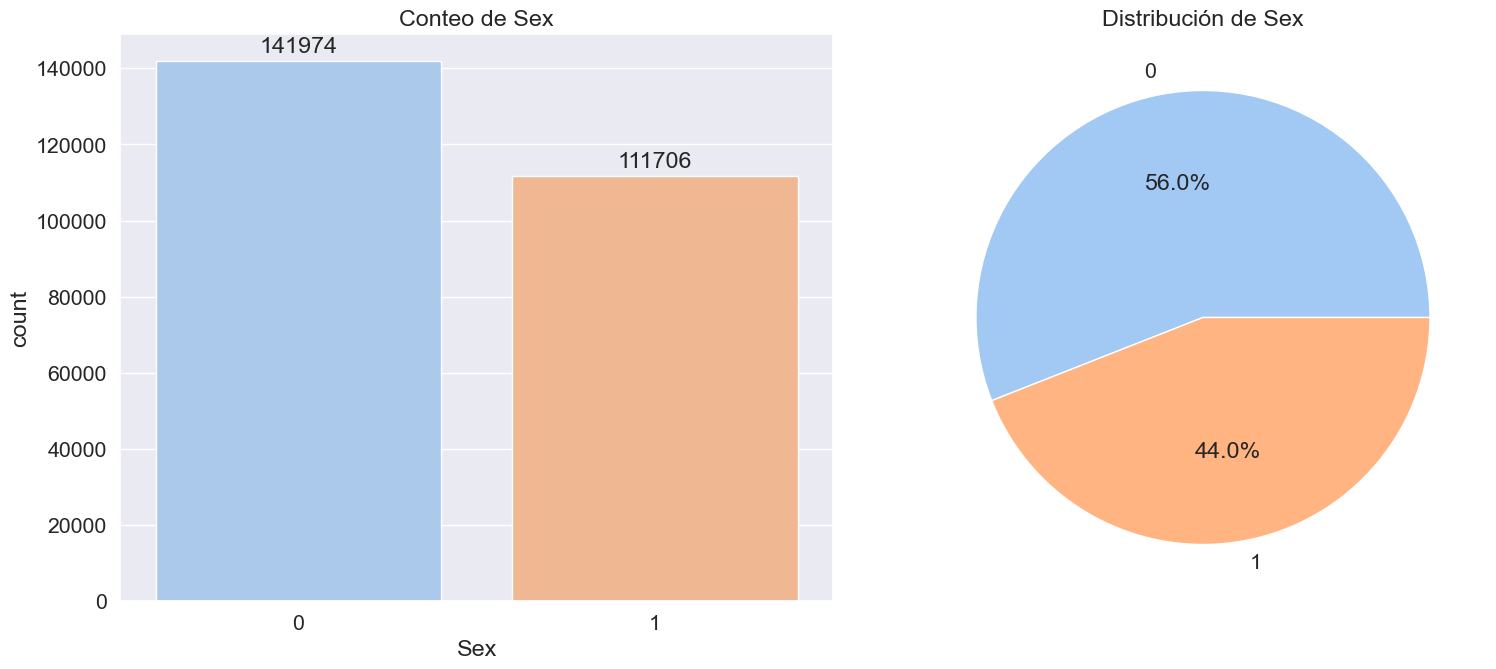

Column: Diabetes_binary


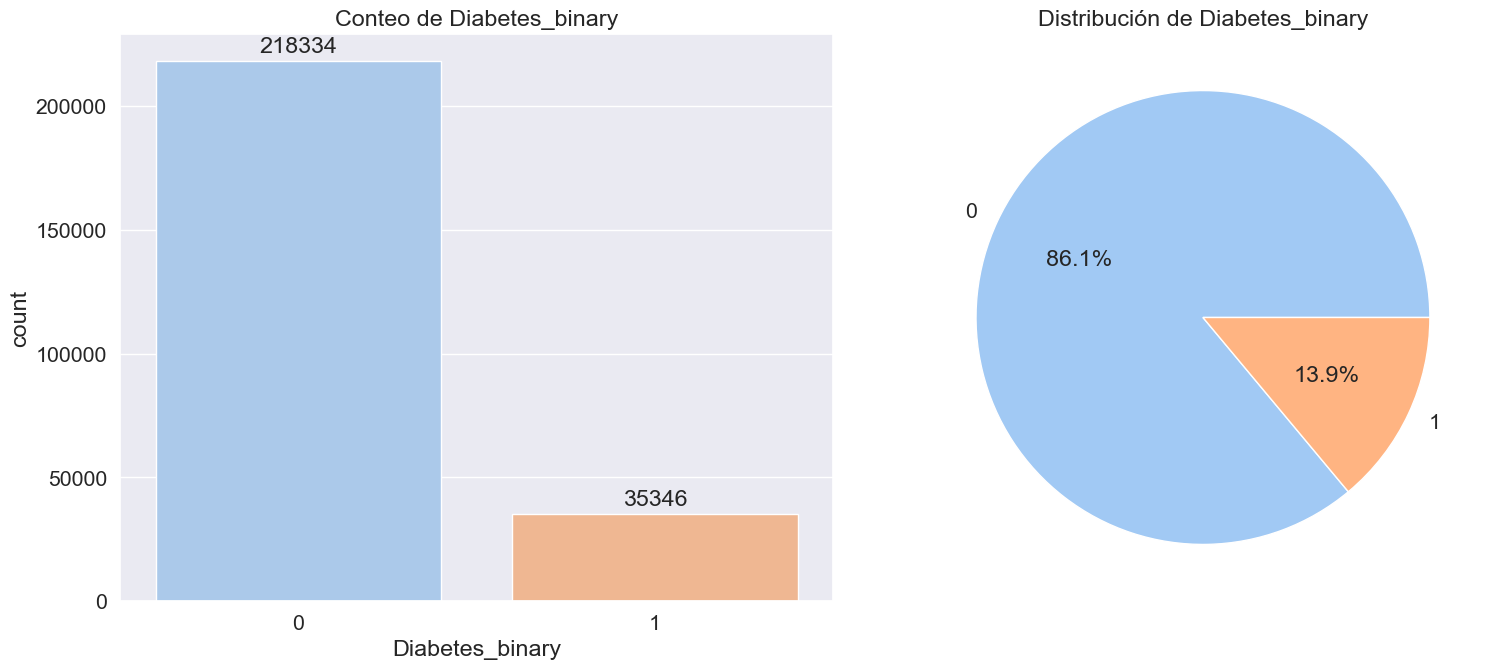

In [21]:
sns.set(font_scale=1.4)
for col in binarias:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Definir el orden y los colores consistentes
    value_order = sorted(df[col].unique())
    colors = sns.color_palette('pastel')  # Misma paleta para ambos gráficos
    
    # Primer subplot - Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    # Añadir los valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    
    # Segundo subplot - Diagrama de torta
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order]  # Ordenar los conteos
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)  # Usar la misma paleta ordenada
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Binarias:**

El análisis de las proporciones revela un marcado desbalance en varias variables binarias, lo que tiene implicaciones importantes para el análisis y modelado:

- Variables con Distribución Relativamente Equilibrada: Algunas características como `HighBP` (42.9% positivos) y `HighChol` (42.4% positivos) presentan una distribución cercana al equilibrio, lo que facilita su análisis sin necesidad de ajustes especiales. Esto sugiere que estas condiciones son comunes en la población estudiada, lo que podría reflejar factores de riesgo prevalentes en el perfil demográfico de la muestra.

- Desbalance Moderado: Variables como `Fruits` (36.6% negativos) y `Veggies` (18.9% negativos) muestran un desbalance moderado. Aunque no son extremos, estos casos podrían beneficiarse de técnicas en modelos predictivos para asegurar que la clase minoritaria tenga suficiente representación en las predicciones.

- Desbalance Extremo: En contraste, variables como `Stroke` (4.1% positivos), `HvyAlcoholConsump` (5.6% positivos) e incluso la variable objetivo `Diabetes_binary` presentan un desbalance pronunciado, donde la clase positiva es significativamente menor. Esto implica riesgos como:

    - Sesgo en Modelos: Los algoritmos podrían ignorar la clase minoritaria al optimizar la precisión global, subestimando patrones críticos.

    - Sobreajuste: Con tan pocos casos positivos, el modelo podría memorizar ruido en lugar de aprender relaciones generalizables.

### Variables Categóricas

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. Cada gráfico muestra:
- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas según su escala natural.

Column: GenHlth


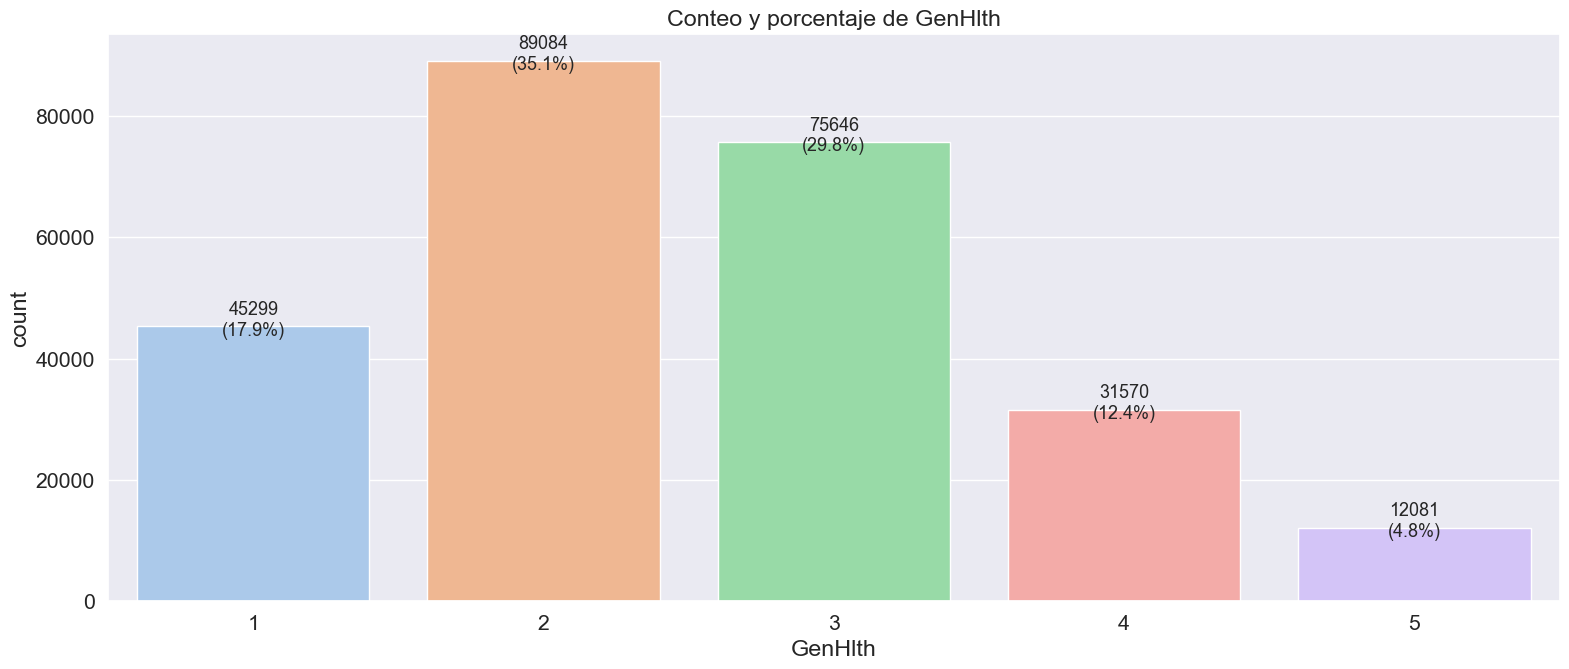

Column: Age


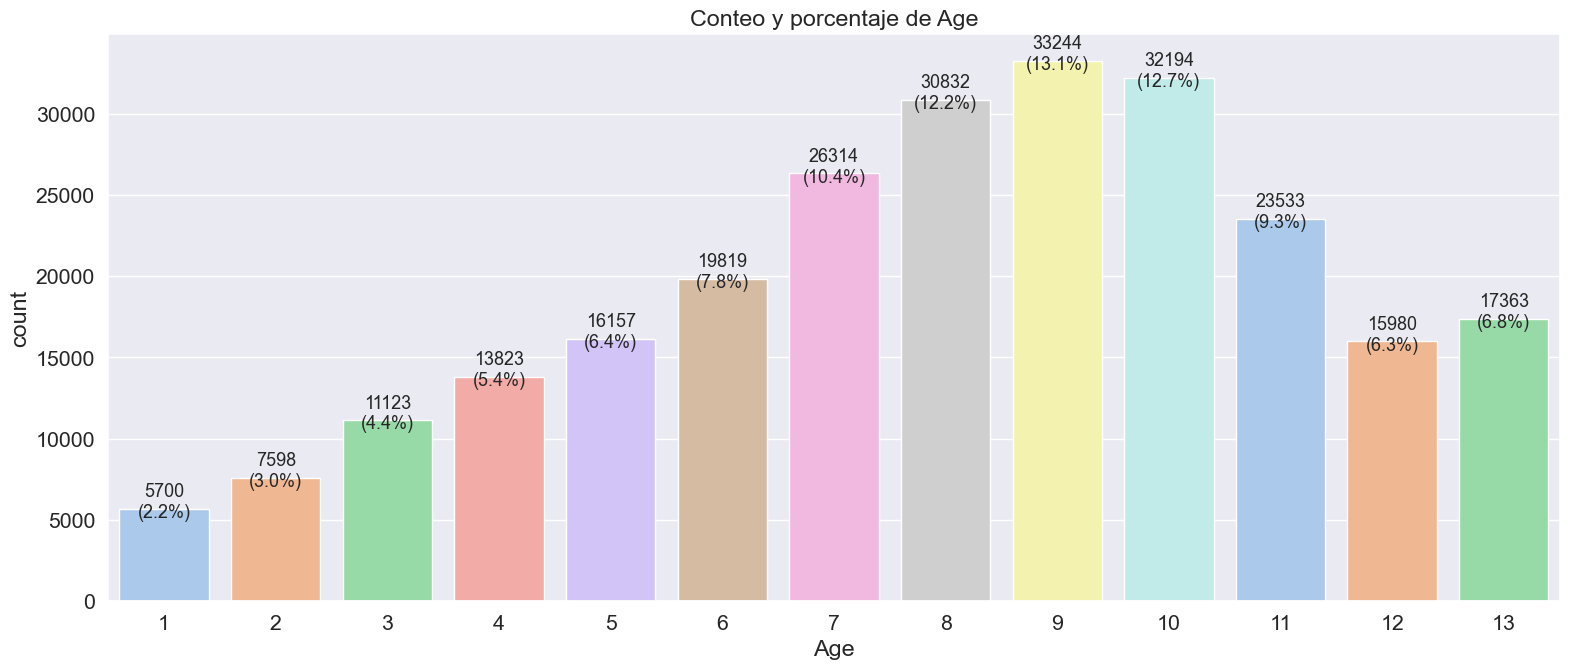

Column: Education


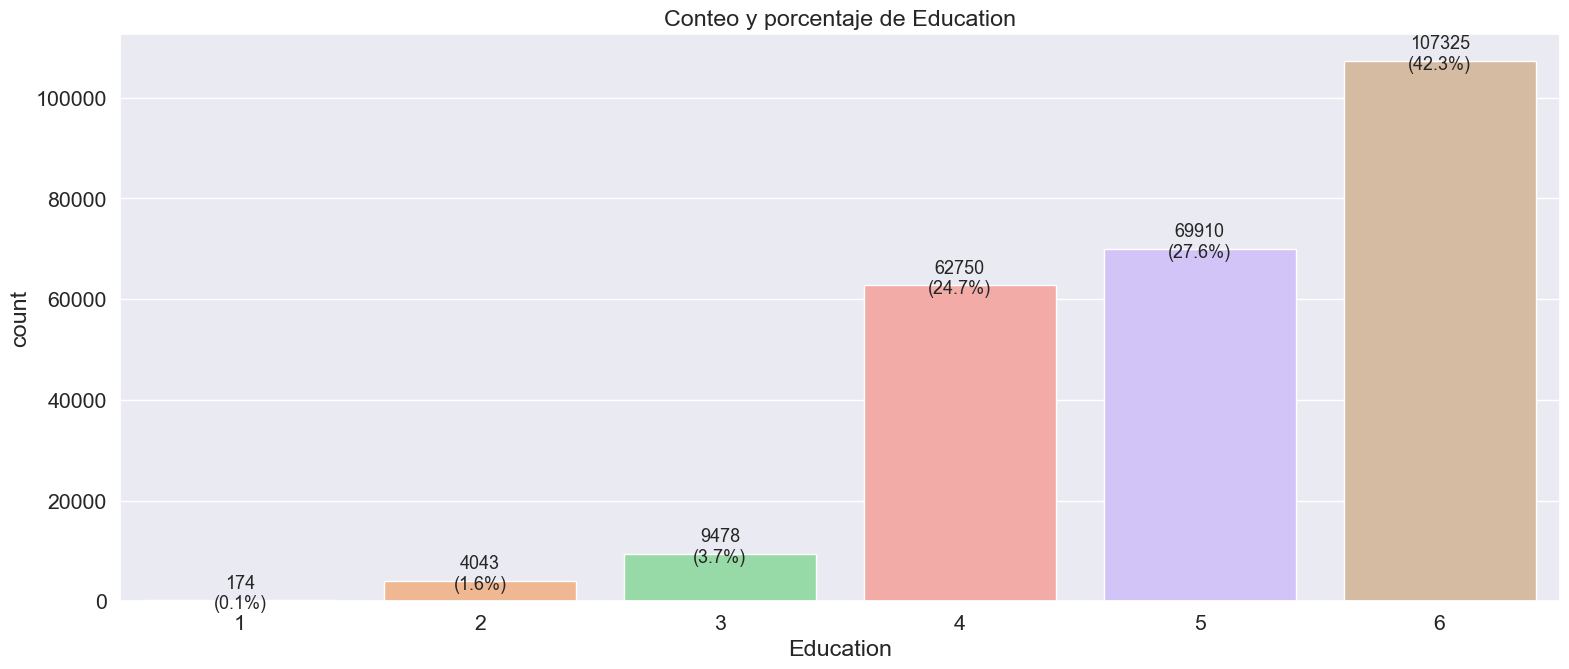

Column: Income


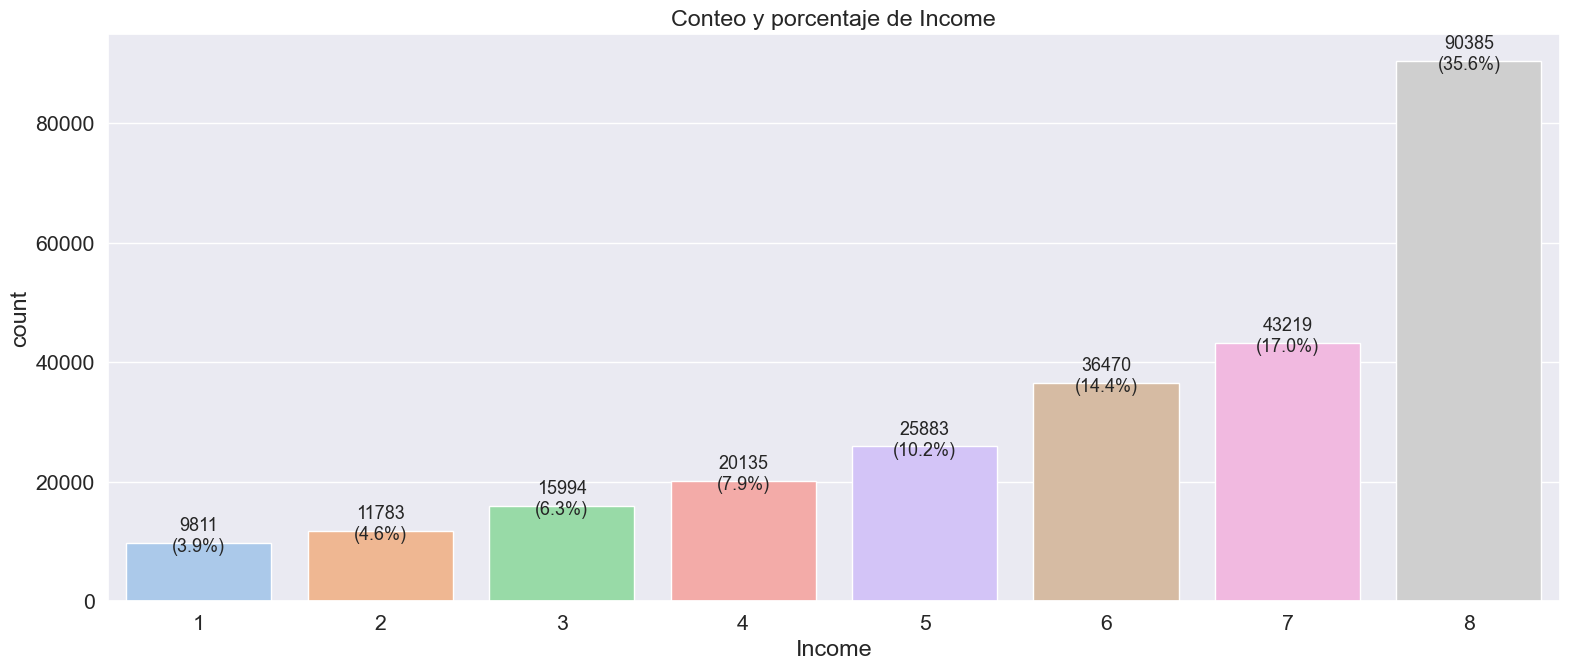

In [10]:
categoricas = ['GenHlth', 'Age', 'Education', 'Income']

sns.set(font_scale=1.4)

for col in categoricas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Obtener el orden de las categorías según el diccionario
    value_order = sorted(df[col].unique())  
    
    # Crear el gráfico de barras ordenado
    ax = sns.countplot(x=df[col], order=value_order, palette='pastel')
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=13)
    plt.title(f'Conteo y porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()
  

**Interpretación de Variables Categóricas:**

El análisis de las distribuciones revela patrones demográficos y socioeconómicos clave en la población estudiada:

- `GenHlth`
La distribución muestra una tendencia hacia percepciones positivas de salud: el 53.0% de los encuestados reporta salud "muy buena" (35.1%) o "excelente" (17.9%), mientras solo el 4.8% la califica como "pobre".

- `Age`
 Se observa una concentración alta en edades entre 50 y 69 años (grupos 7 a 10), lo cual sugiere que la mayoría de los participantes o casos en este conjunto de datos son personas de mediana edad a adultos mayores. Los grupos con menor representación son:
    - 18–24 años (grupo 1): 5,700 personas (2.2%).
    - 25–29 años (grupo 2): 7,598 personas (3.0%),
Esto indica que hay menos jóvenes en el conjunto de datos, posiblemente porque se trata de una muestra relacionada con condiciones de salud que afectan más a personas mayores.

-  `Education`
Se observa una marcada sobrerrepresentación de educación superior: el 42.3% corresponde a graduados universitarios (categoría 6), seguido por "algo de universidad" (27.6%). Esto se evidencia al compararlo con el 0.1%, 1.6% y 3.7% de las categorias 1, 2 y 3 respectivamente. Este perfil sugiere un sesgo de selección hacia población con mayor acceso a educación, lo que podría limitar la generalización de hallazgos a grupos menos educados.

- `Income`
La distribución económica muestra una concentración en la clase media-alta: el 35.6% pertenece a la categoría más alta, seguido por la segunda categoría mas alta con 17%. Esta estructura, combinada con los datos educativos, refuerza la hipótesis de que la muestra subrepresenta poblaciones vulnerables.

### Variables Númericas

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [11]:
df[['MentHlth', 'PhysHlth','BMI']].describe().T

,count,mean,std,min,25%,50%,75%,max
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0


**Interpretación de Variables Númericas:**

- `MentHlth`: Los participantes reportaron un promedio de 3.18 días con salud mental afectada en los últimos 30 días. Con una desviación estándar de 7.41 días, indicando una variabilidad moderada en las respuestas.
- `PhysHlth`: El promedio fue ligeramente mayor (4.24 días), sugiriendo que los problemas físicos son más frecuentes que los mentales en esta muestra. Con una dispersión mayor (desviación estándar de 8.72 días), lo que sugiere que los problemas físicos muestran mayor variabilidad entre los individuos.

Ambas variables comparten un patrón similar en los percentiles:
- 25% inferior: 0 días de afectación.
- Mediana (50%): 0 días.
- 75% superior: 2 días para salud mental y 3 días para salud física.

Este patrón revela que la mayoría de la población (al menos 50%) no reportó días con problemas de salud.

- `BMI`: El Índice de Masa Corporal (BMI) muestra una media de 28.38 y una desviación estándar de 6.61, indicando que la mayoría de los valores se agrupan alrededor de 28.38, con una dispersión moderada. La distribución está sesgada hacia valores más altos.
    - Mediana (50%): 27.0 < Media (28.38), lo que sugiere una cola derecha (presencia de valores atípicos altos).
    - Rango intercuartílico (IQR): 7.0 (Q3-Q1 = 31.0 - 24.0), capturando el 50% central de los datos.
    - Valores extremos: El mínimo (12.0) y máximo (98.0) son atípicos, especialmente el máximo (98.0), que está muy alejado del percentil 75% (31.0).

---

Se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- Asimetría:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- Kurtosis: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

Column: MentHlth
Skew: 2.72
Kurtosis:  6.44


<Figure size 1600x700 with 0 Axes>

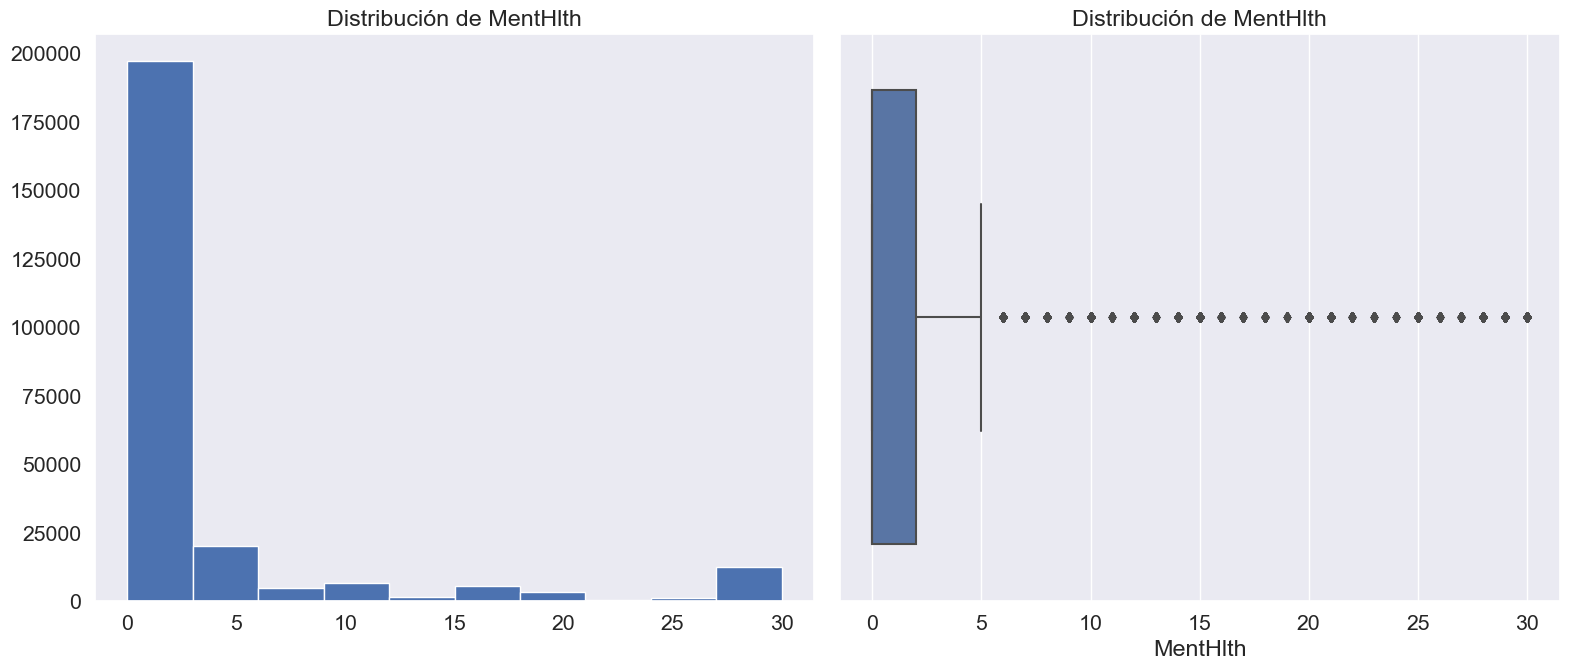

Column: PhysHlth
Skew: 2.21
Kurtosis:  3.5


<Figure size 1600x700 with 0 Axes>

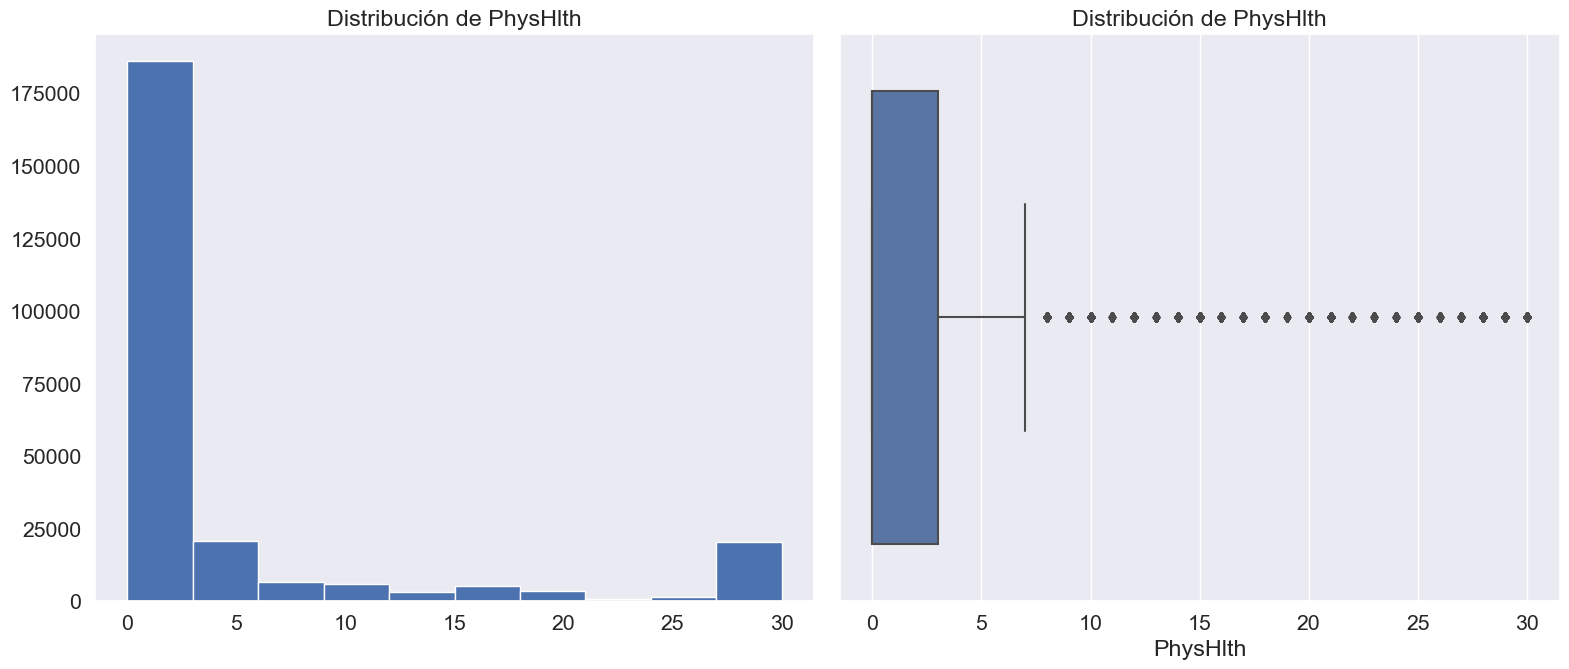

Column: BMI
Skew: 2.12
Kurtosis:  11.0


<Figure size 1600x700 with 0 Axes>

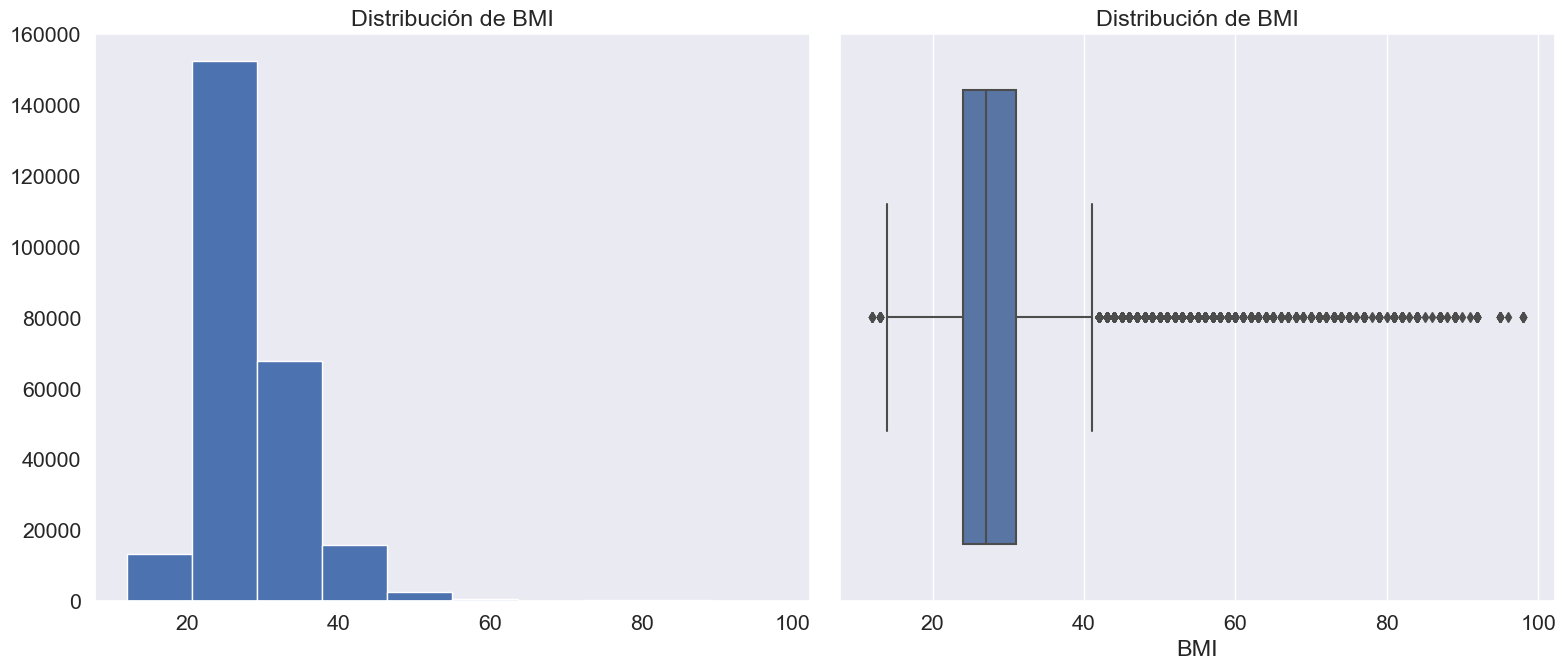

In [12]:
numericas = ['MentHlth', 'PhysHlth', 'BMI']

from scipy.stats import kurtosis

sns.set(font_scale=1.4)

for col in numericas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    plt.figure(figsize = (16, 7))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False)
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Númericas:**

Los datos muestran que la variable `MentHlth` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.72) con una kurtosis elevada (6.44), indicando:
- Una concentración extrema de valores bajos (cerca de 0 días).
- Una larga cola hacia valores altos.
- Presencia significativa de outliers, como evidencia el boxplot.
Esta distribución sugiere que la mayoría de la población reporta pocos o ningún día de afectación mental, mientras que un pequeño grupo muestra afectación persistente.

La variable `PhysHlth` también muestra sesgo positivo (skewness = 2.21) pero con una kurtosis menos pronunciada (3.5), lo que revela:
- Similar concentración en valores bajos.
- Cola derecha menos extrema que MentHlth.
- Menor cantidad de outliers extremos.

Los datos muestran que la variable `BMI` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.12) con una kurtosis muy elevada (11.0), lo que indica:
- Una concentración extrema de valores en el rango bajo a moderado (probablemente entre 20-30).
- Una cola derecha muy larga que se extiende hacia valores altos de BMI.
- Presencia significativa de outliers extremos en los valores superiores.

Esta distribución sugiere que:
- La mayoría de la población tiene valores de BMI dentro del rango normal o ligeramente elevado.
- Existe un grupo más pequeño pero significativo con obesidad moderada.
- Un grupo muy reducido presenta valores extremadamente altos (obesidad mórbida).

La kurtosis excepcionalmente alta (11.0 vs 3.5 en PhysHlth) indica que:
- Los datos están mucho más concentrados alrededor de la media que en una distribución normal.
- Las colas son más pesadas de lo esperado.
- Los outliers son más extremos que en otras variables de salud analizadas.

Comparado con `MentHlth` y `PhysHlth`:
- El sesgo es similar pero ligeramente menos pronunciado.
- La kurtosis es notablemente más alta, mostrando mayor concentración en valores centrales.
- Los outliers parecen ser más extremos en BMI que en las variables de salud mental/física, debido a que en las variables de percepción el rango va desde 0 a 30 días del mes, en cambio el BMI no tiene limite.

En estos casos podemos realizar una transformación logarítmica que puede ayudar en la normalización, por lo que esta variable puede mantener la escala estándar con otras variables.

## Análisis Bivariado

Se generan graficos de barras para analizar la relación entre un conjunto de variables binarias y la presencia de diabetes con el fin de identificar qué variables binarias están asociadas a mayores proporciones de diabetes en el conjunto de datos.

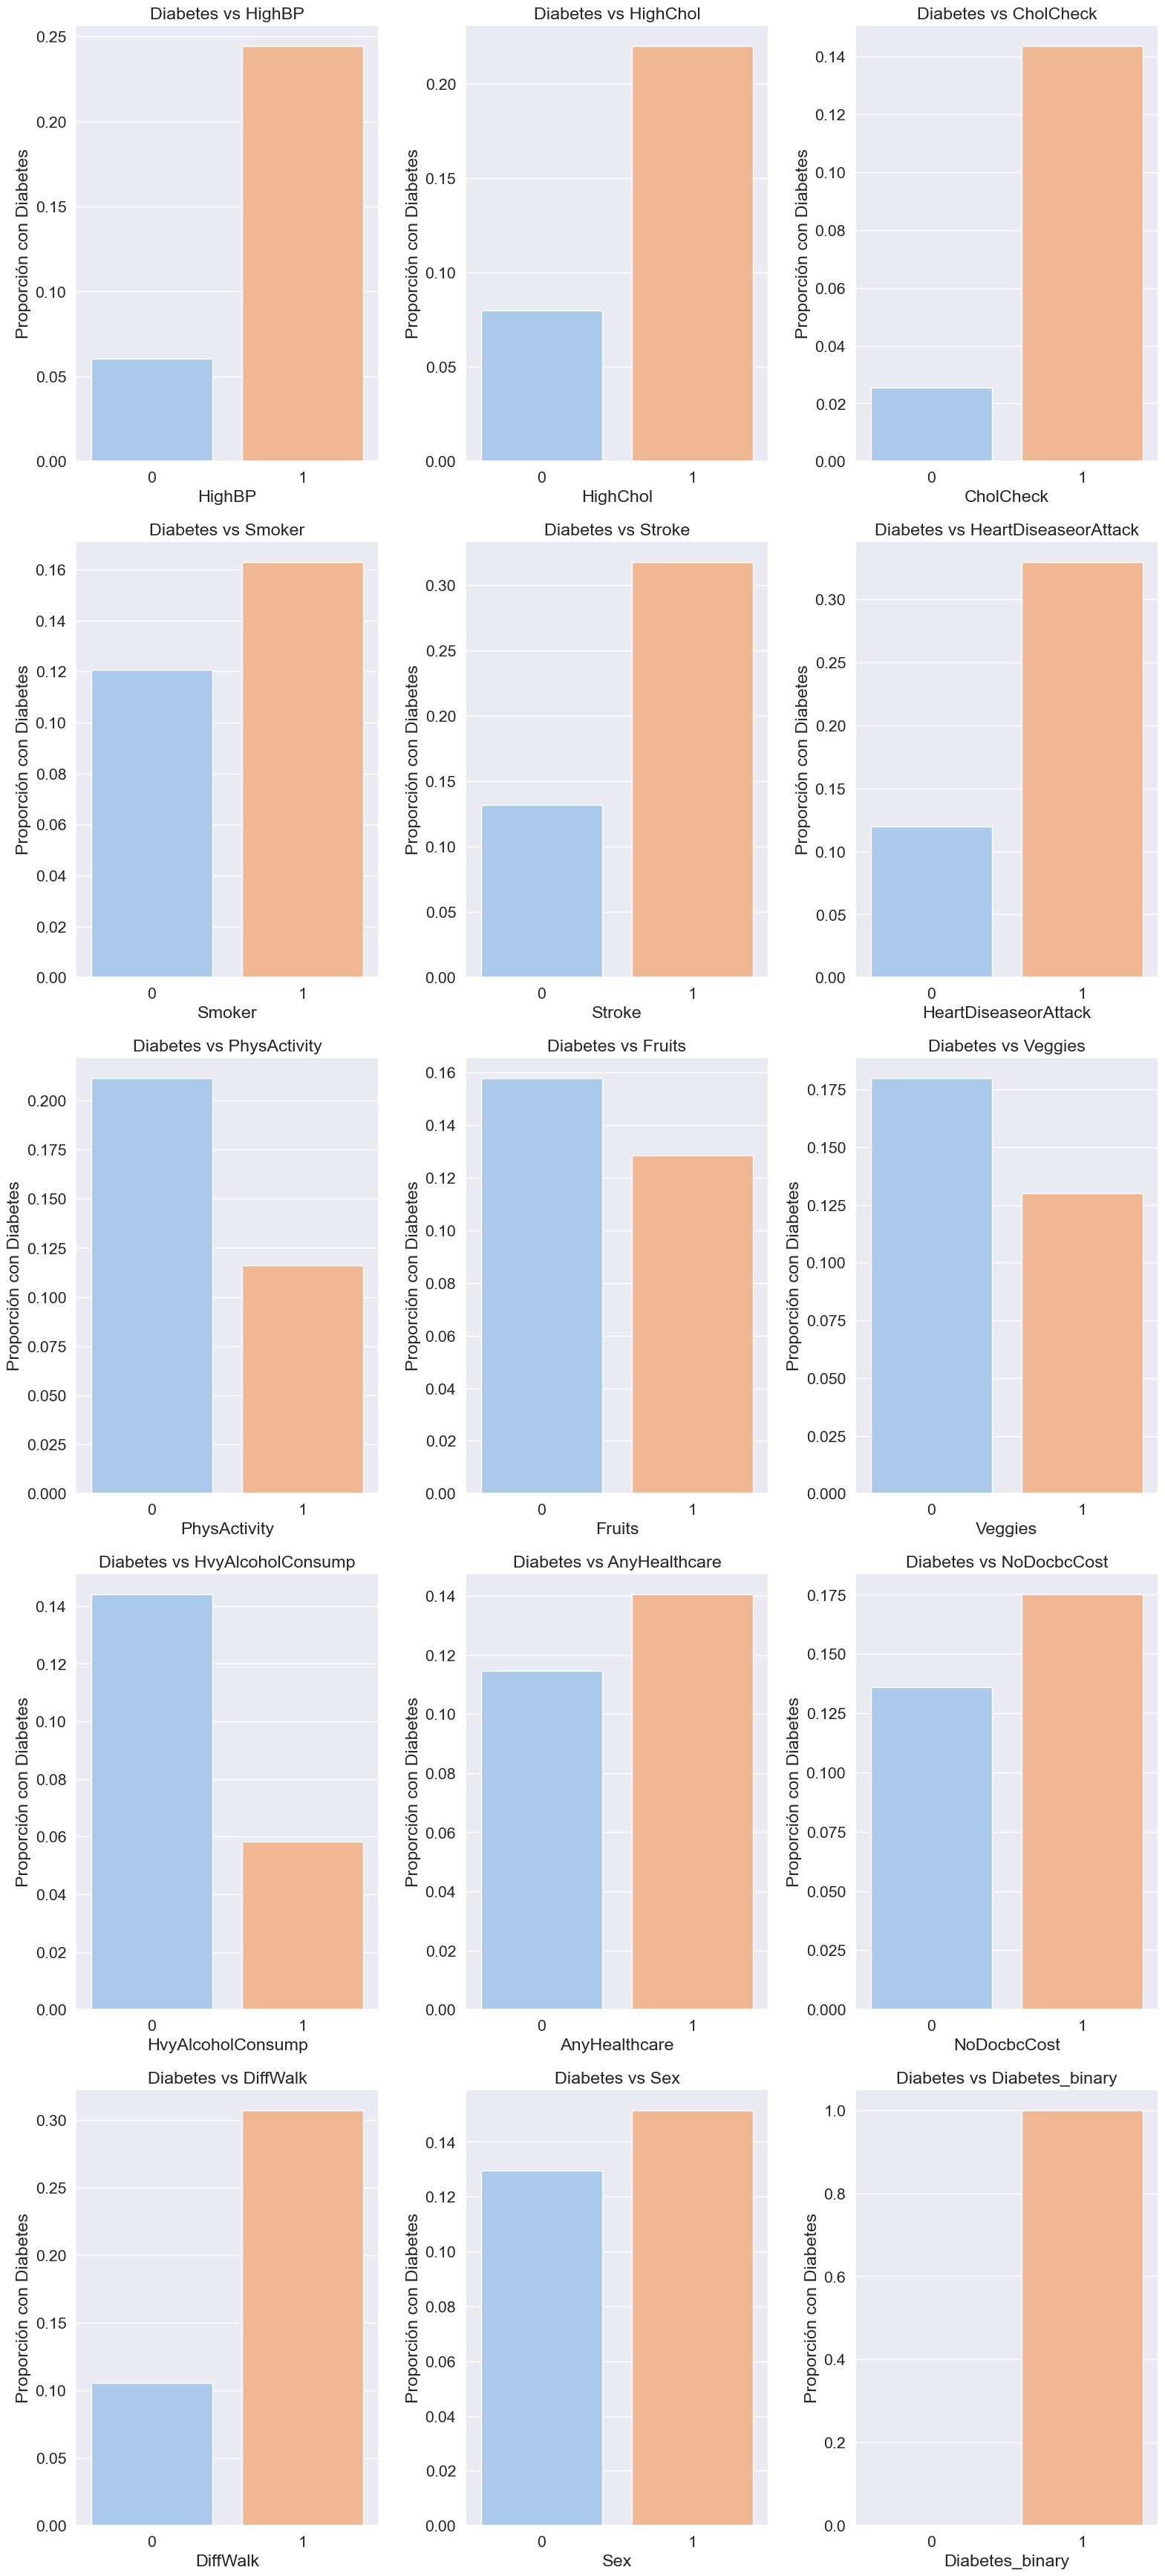

In [13]:
sns.set(font_scale=1.4)

plt.figure(figsize=(16, 7 * 5)) 

for i, col in enumerate(binarias, 1):  
    plt.subplot(5, 3, i) 
    sns.barplot(
    x=col, 
    y='Diabetes_binary', 
    data=df, 
    palette='pastel',
    errorbar=None
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
plt.tight_layout()  
plt.show()

**Interpretación:**

Los resultados visualizados muestran que la proporción de personas con diabetes es notablemente mayor en aquellos que presentan condiciones crónicas como hipertensión, colesterol alto, enfermedades cardiovasculares, antecedentes de derrame cerebral y dificultades físicas para caminar. Esta tendencia sugiere una fuerte asociación entre la diabetes y la presencia de otras enfermedades no transmisibles. Además, se observa que ciertos comportamientos y estilos de vida, como la inactividad física y el consumo de tabaco, también están relacionados con una mayor prevalencia de diabetes. Por otro lado, factores como la actividad física regular y una alimentación con frutas y verduras parecen asociarse con una menor proporción de personas con diabetes. Finalmente, las barreras económicas y el acceso limitado a servicios de salud también muestran una posible relación con una mayor proporción de casos, lo cual resalta la importancia del contexto socioeconómico en el manejo y prevención de esta enfermedad. En conjunto, los gráficos evidencian que la diabetes no solo está influenciada por condiciones médicas, sino también por determinantes sociales y conductuales de la salud.

---

Se generan graficos de barras para analizar la relación entre variables categóricas y la presencia de diabetes en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de diabetes, lo que podría indicar posibles factores de riesgo asociados.

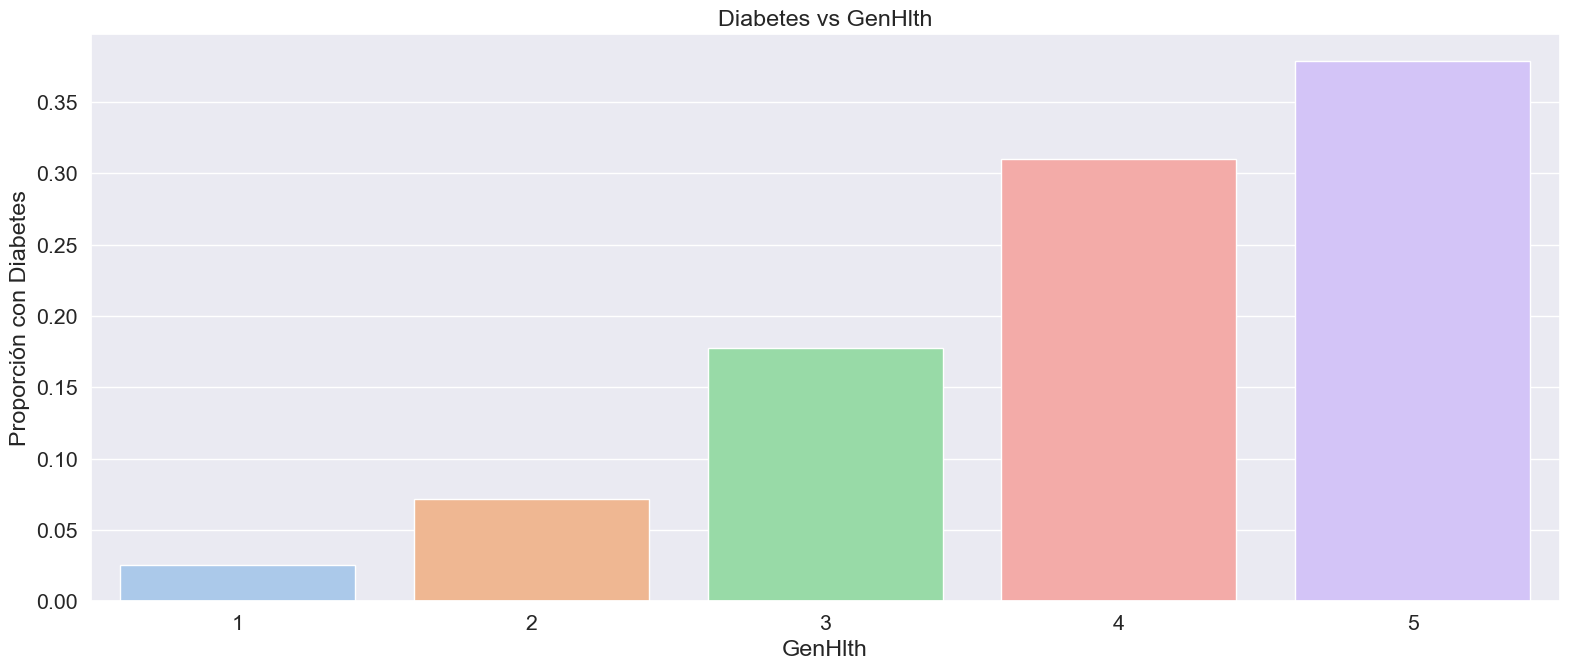

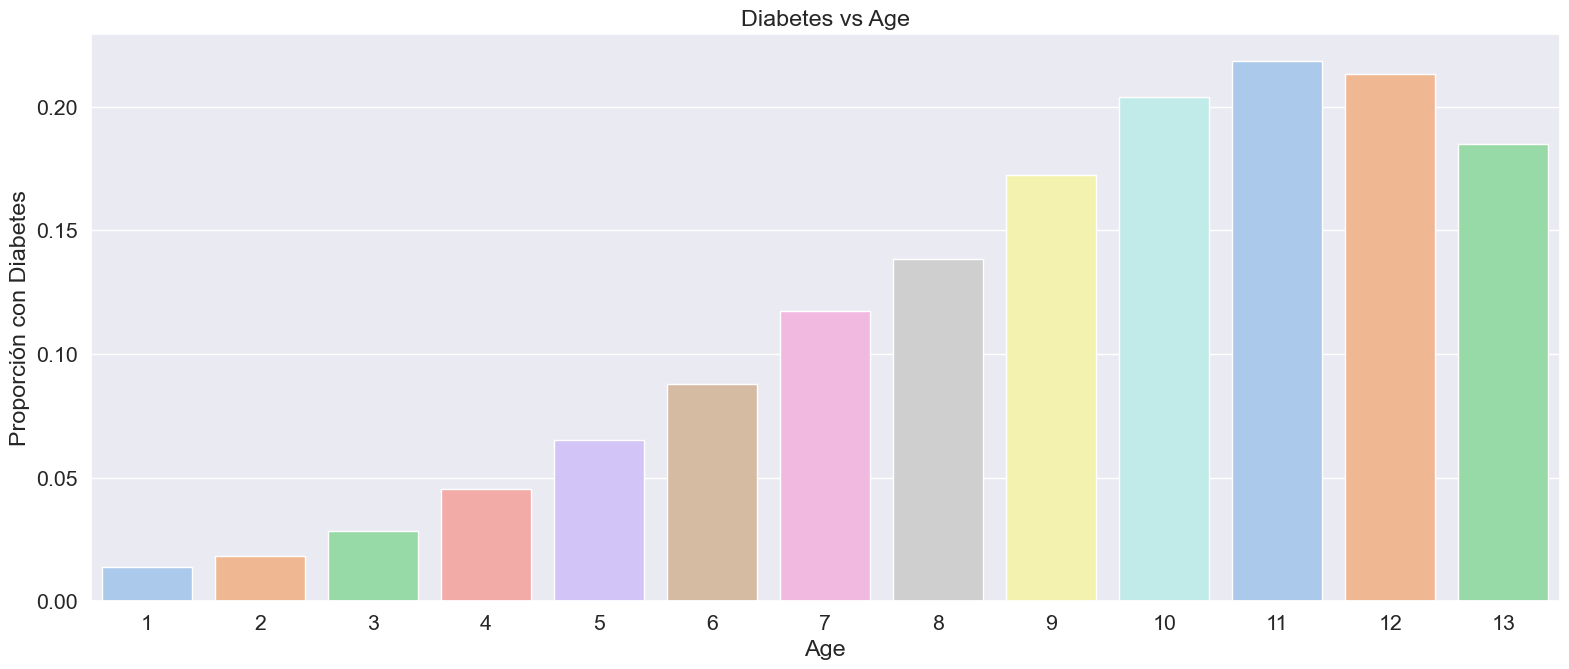

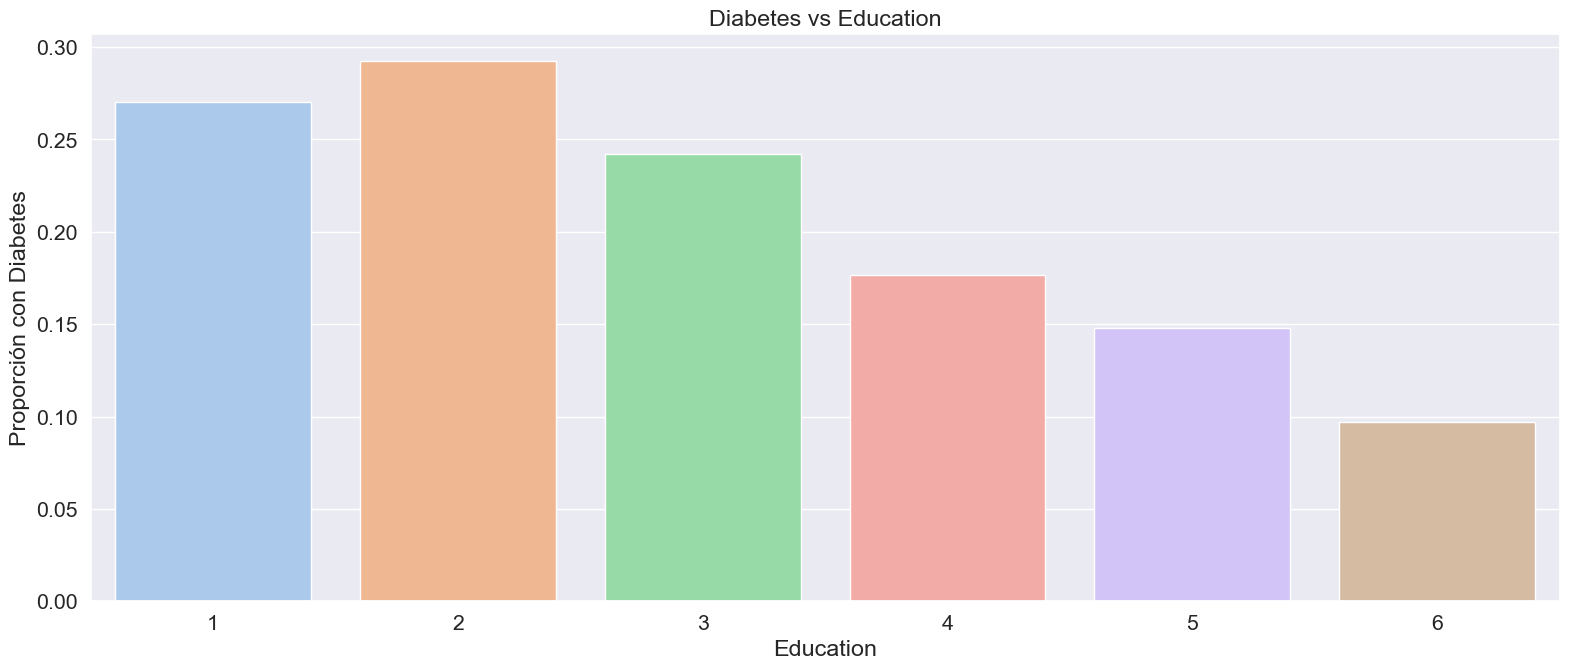

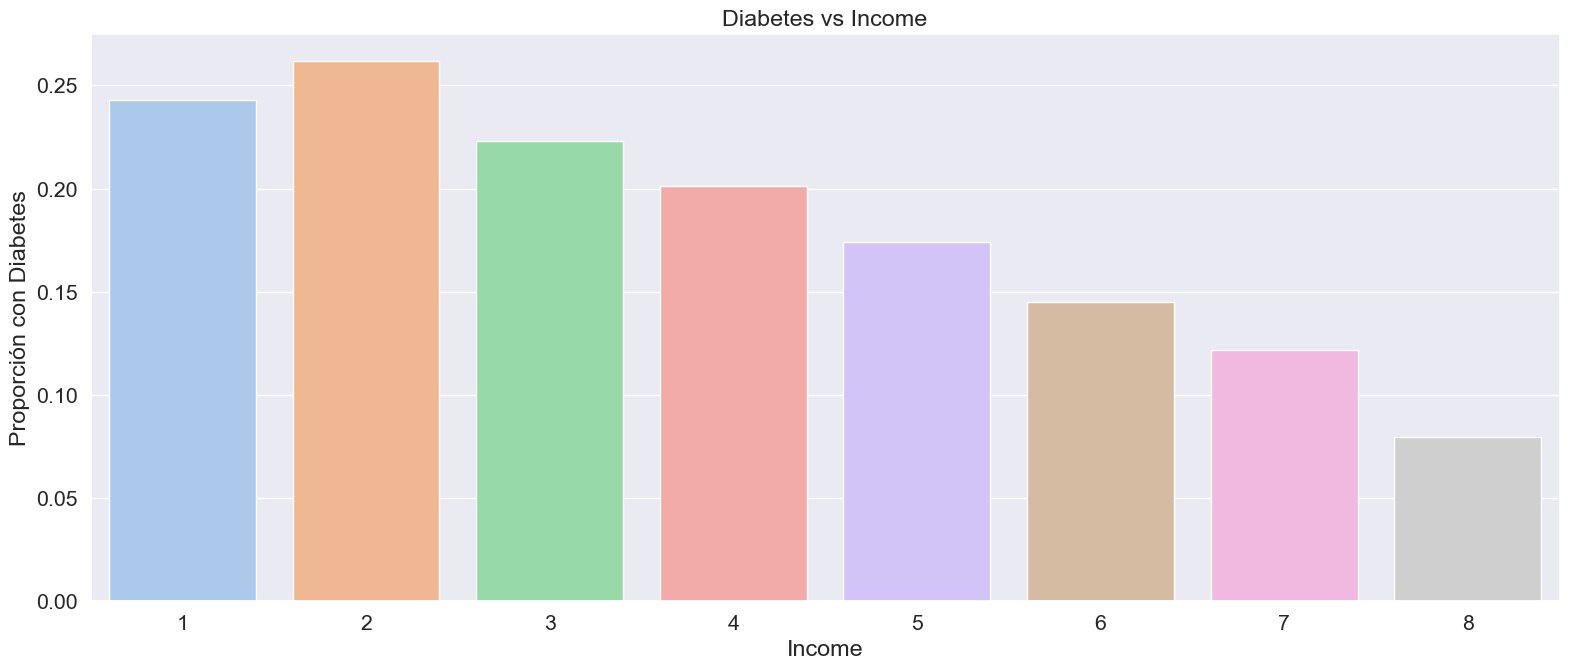

In [14]:
sns.set(font_scale=1.4)

for col in categoricas:
    
    plt.figure(figsize=(16, 7))
    sns.barplot(
        x=col, 
        y='Diabetes_binary', 
        data=df, 
        palette='pastel',
        errorbar=None  
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
    plt.tight_layout()
    plt.show()

**Interpretación:**

Los resultados muestran una relación clara entre la proporción de personas con diabetes y diversas variables sociodemográficas. En cuanto al estado general de salud percibido `GenHlth`, se observa que a medida que las personas reportan una peor salud (del valor 1 al 5), la proporción de casos de diabetes aumenta progresivamente, lo que indica una fuerte asociación entre la autopercepción negativa de la salud y la presencia de diabetes. En relación con la `Age`, los datos revelan una tendencia ascendente en la proporción de diabetes conforme se avanza en los grupos etarios, alcanzando su punto máximo en los grupos de mayor edad, lo que sugiere que la diabetes es más común en adultos mayores. Por otro lado, los niveles de `Education` muestran una tendencia inversa: las personas con menor nivel educativo presentan una mayor proporción de diabetes, mientras que a mayor nivel educativo, esta proporción disminuye gradualmente. Esta misma tendencia se refleja en los niveles de `Income`, donde las personas con ingresos más bajos muestran una mayor prevalencia de diabetes en comparación con aquellas que pertenecen a grupos de ingresos más altos. En conjunto, estos resultados evidencian la influencia significativa de factores sociales como la edad, la educación, el ingreso económico y la percepción de salud en la prevalencia de la diabetes, resaltando la importancia de abordar esta enfermedad desde un enfoque multidimensional..

---

Se visualiza la asociación entre variables numéricas y la diabetes. Los gráficos combinan barras (proporción de diabetes por categoría) y una línea de tendencia (roja), permitiendo identificar patrones o relaciones monotónicas entre las variables y la variable objetivo.

c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\relational.py:441: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.a

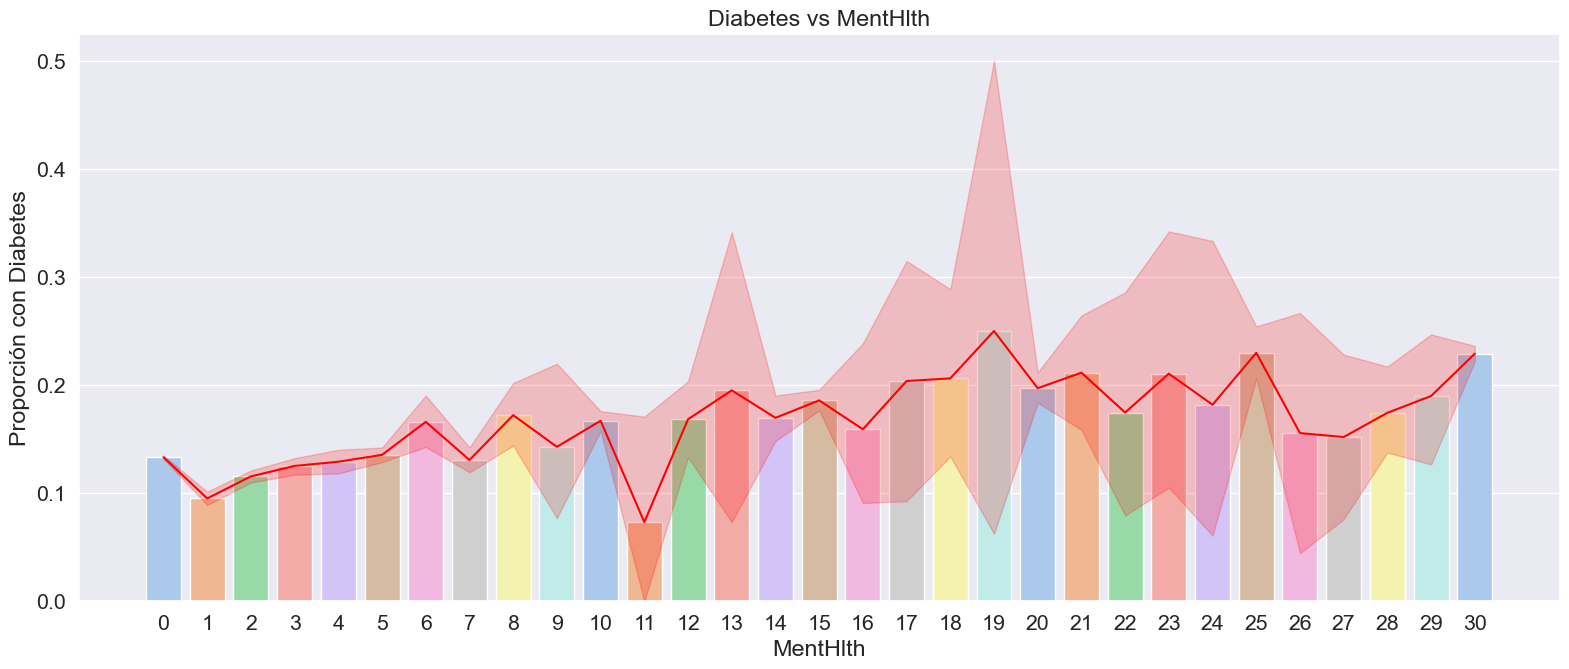

c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\relational.py:441: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.a

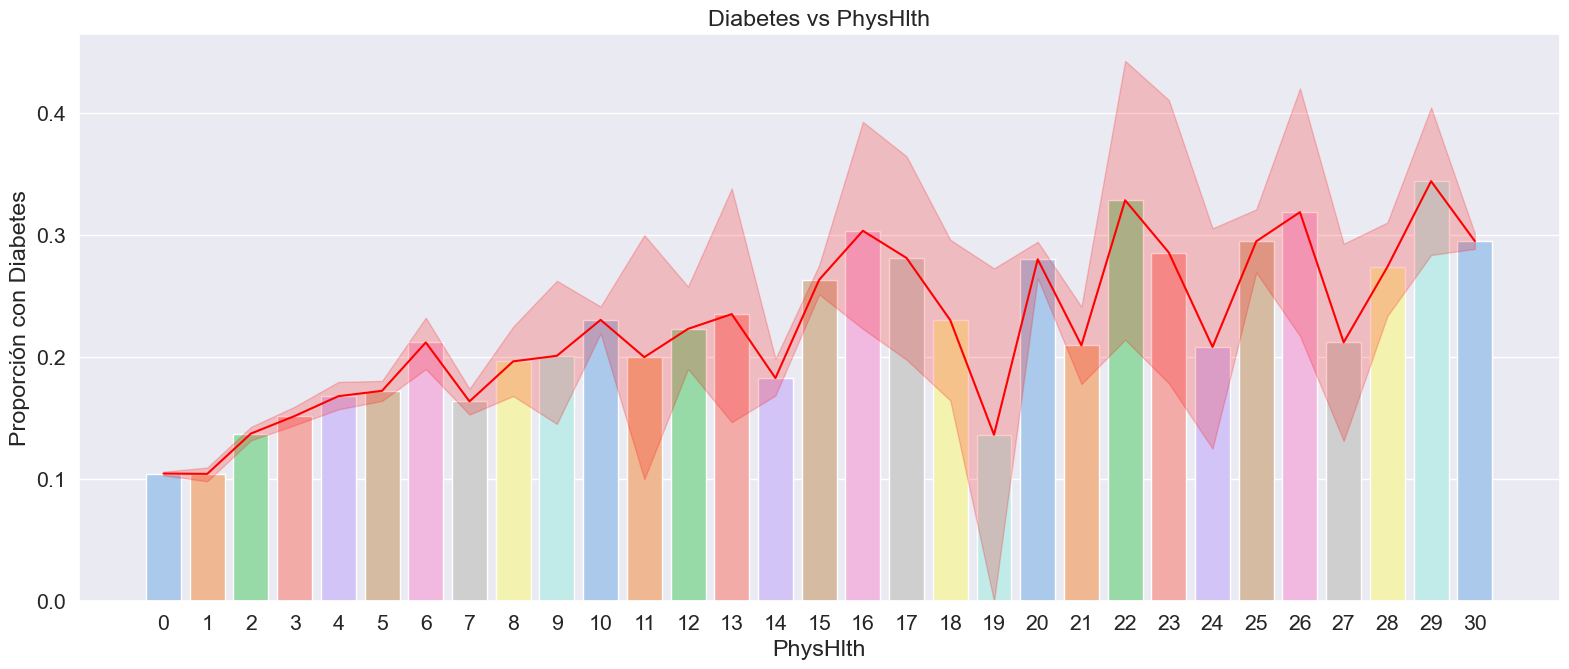

c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\david\miniconda3\envs\ml_venv\lib\site-packages\seaborn\relational.py:441: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.a

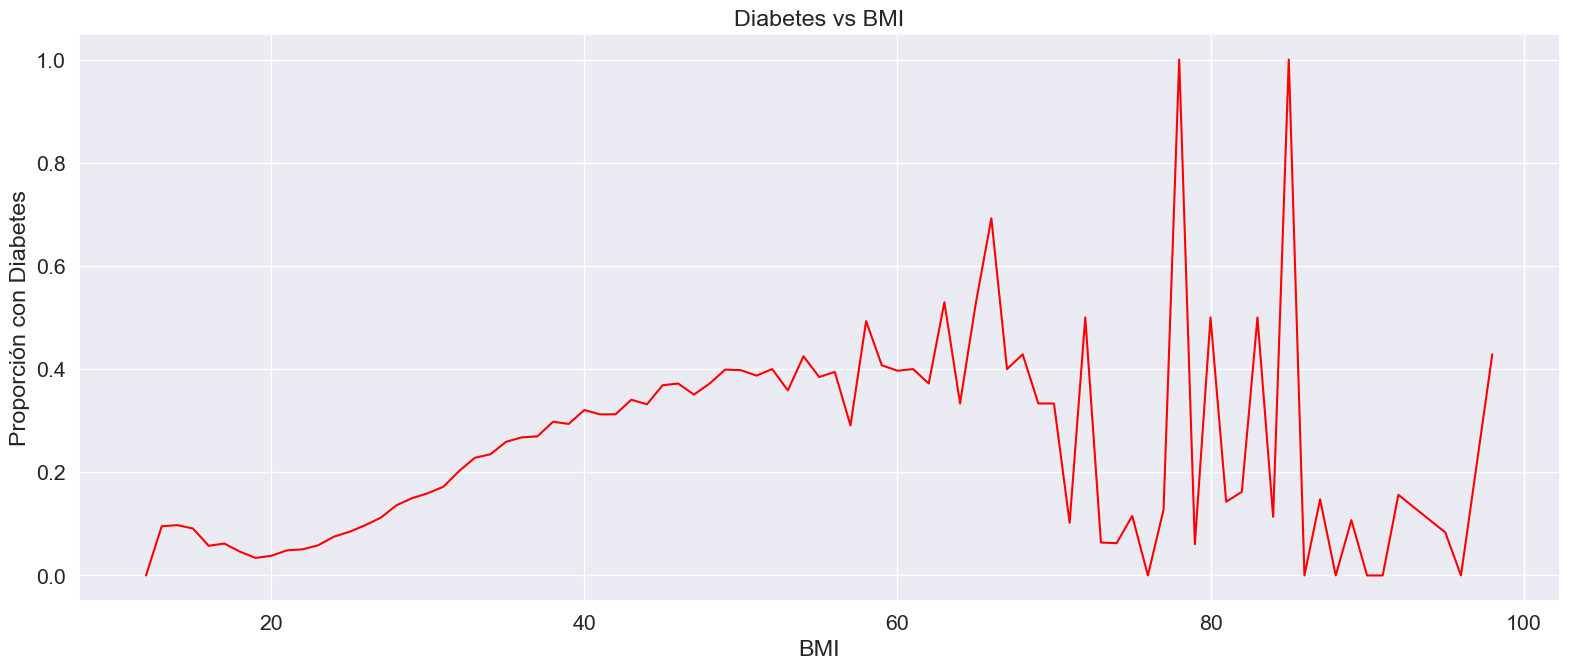

In [15]:
sns.set(font_scale=1.4)

for col in numericas:
    
    if (col != "BMI"):
        plt.figure(figsize=(16, 7))
        sns.barplot(
            x=col, 
            y='Diabetes_binary', 
            data=df, 
            palette='pastel',
            errorbar=None  
        )
        
        sns.lineplot(
        x=col, 
        y='Diabetes_binary', 
        data=df,
        color='red',
        sort=True
        )
        plt.title(f'Diabetes vs {col}')
        plt.ylabel('Proporción con Diabetes')
        plt.tight_layout()
        plt.show()
        
             
plt.figure(figsize=(16, 7))
sns.lineplot(
    x='BMI', 
    y='Diabetes_binary', 
    data=df,
    color='red',
    estimator='mean', 
    errorbar=None
)
plt.title('Diabetes vs BMI')
plt.ylabel('Proporción con Diabetes')
plt.tight_layout()
plt.show()

**Interpretación:**

Los gráficos muestran la relación entre la salud mental `MentHith` y física `PhysHith` con la proporción de casos de diabetes. En ambos casos, se observa una tendencia clara: a medida que empeora el estado de salud (aumentan los valores en los ejes horizontales), la proporción de personas con diabetes incrementa. Para la salud mental, la línea de tendencia roja presenta un ascenso sostenido, aunque con cierta variabilidad en los valores intermedios, lo que sugiere que los días con mayor afectación mental están asociados a una mayor prevalencia de diabetes. Por otro lado, en la salud física, la tendencia es más marcada y consistente, especialmente en los valores más altos, indicando una fuerte correlación entre el deterioro físico y la presencia de diabetes. Estos resultados refuerzan la hipótesis de que tanto la salud mental como física están vinculadas al riesgo de diabetes, siendo el impacto particularmente evidente en estados de salud más críticos.

El gráfico de la relación entre el `BMI` y la presencia de diabetes muestra un comportamiento poco claro para valores superiores a 60 BMI. Esta inconsistencia se debe a la escasez de muestras en dicho rango, lo que provoca cambios bruscos en la proporción de casos con diabetes. Por ejemplo, en un valor específico de BMI podría registrarse que el 100% de las pocas muestras tienen diabetes, mientras que en el siguiente valor (igualmente extremo) la proporción caería abruptamente a 0%. Este fenómeno refleja una la alta variabilidad en regiones con baja densidad de muestras, lo que dificulta la interpretación de tendencias. 

---

Para evaluar la tendencia entre las variables númericas y la prevalencia de diabetes de manera más clara se implementó un análisis basado en categorización de rangos.

C:\Users\david\AppData\Local\Temp\ipykernel_9468\2871714856.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100


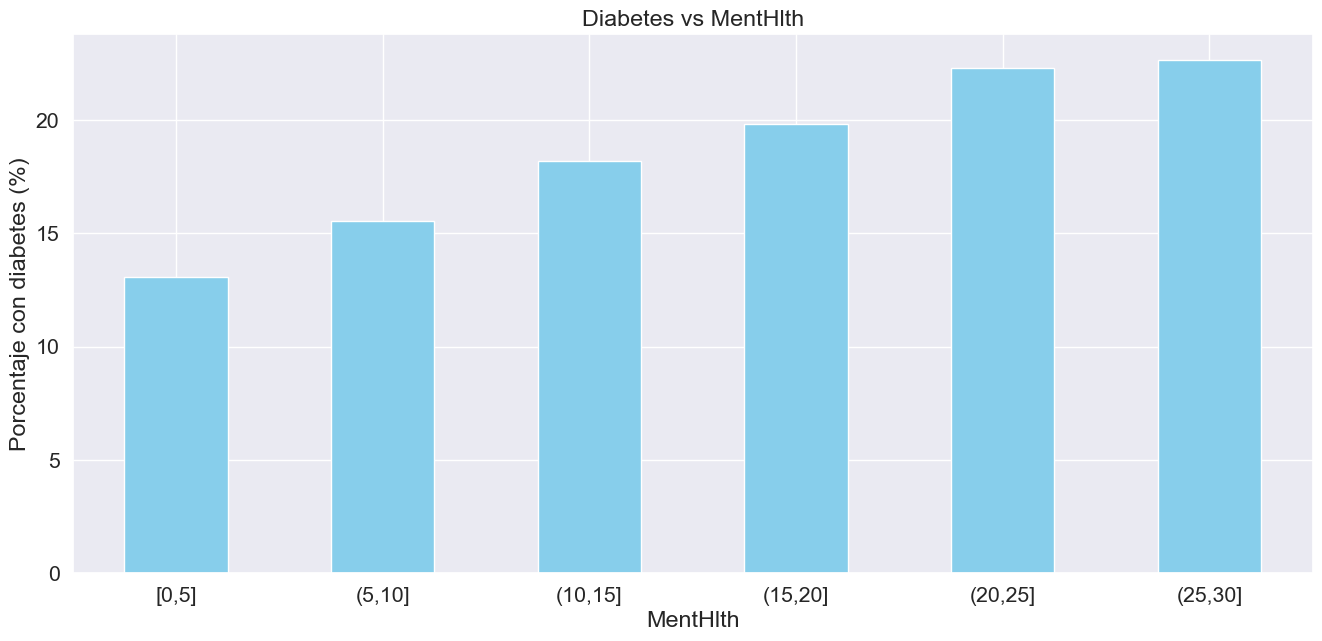

C:\Users\david\AppData\Local\Temp\ipykernel_9468\2871714856.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100


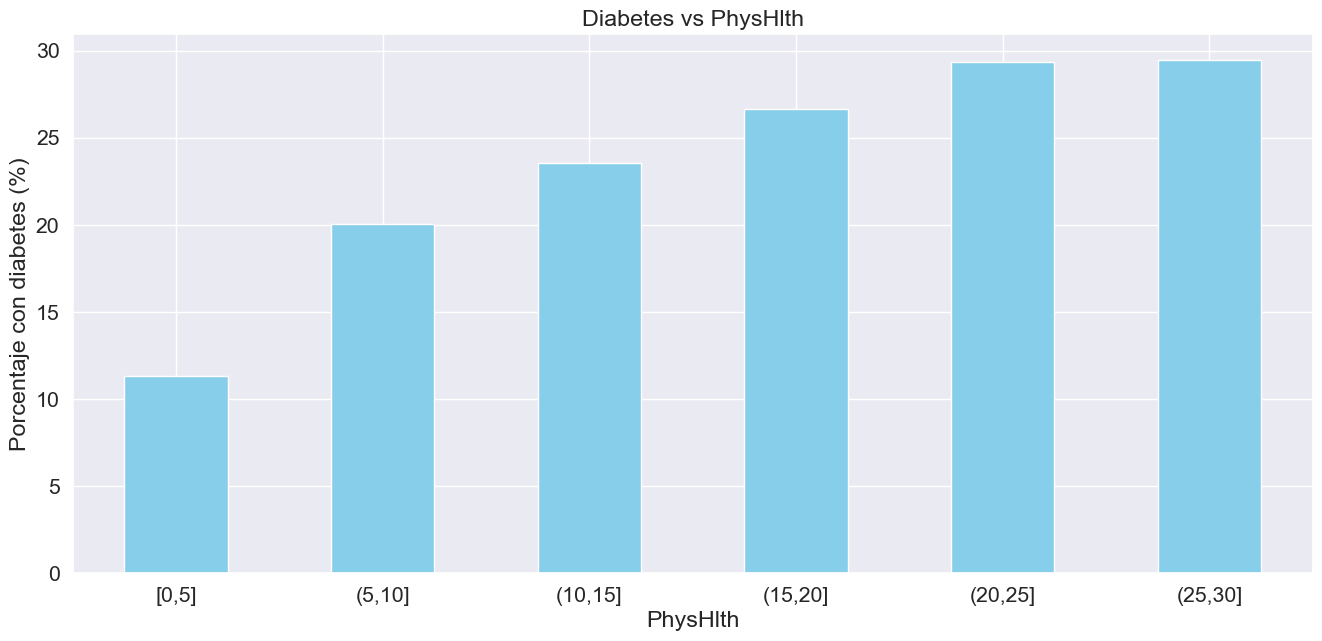

C:\Users\david\AppData\Local\Temp\ipykernel_9468\2871714856.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100


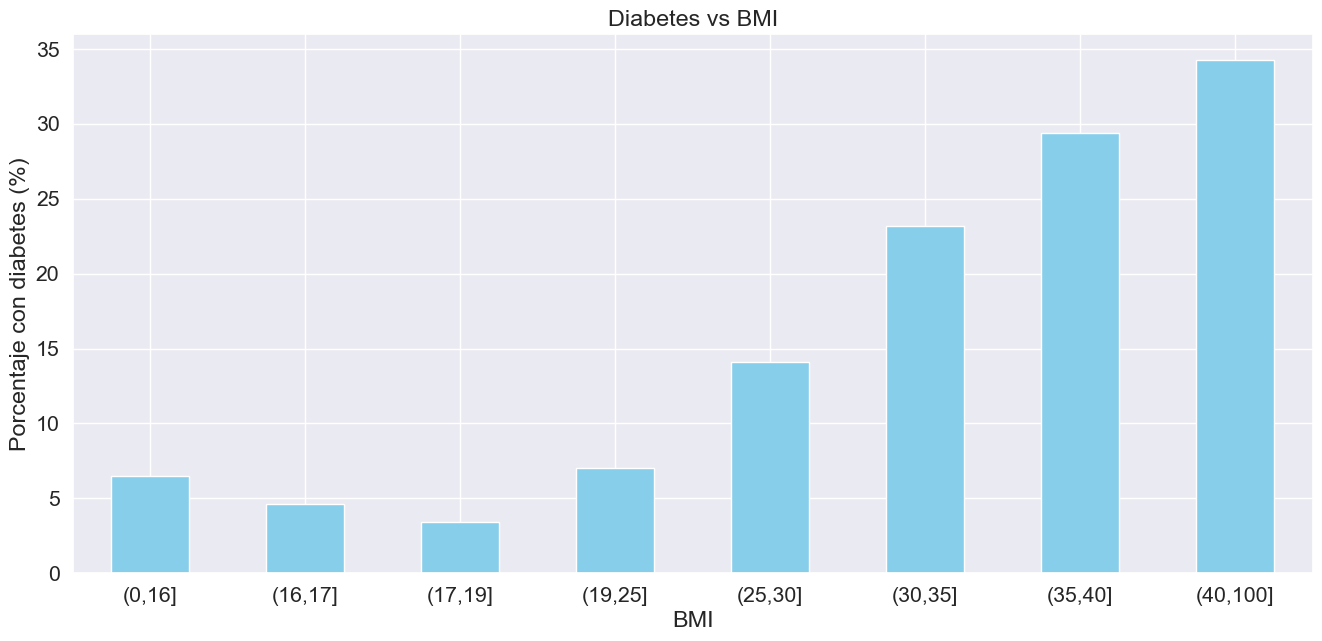

In [16]:
# Diccionario con bins y labels para cada variable
config_categorias = {
    "BMI": {
        "bins": [0, 17, 18, 19, 26, 31, 36, 41, 100],
        "labels": ['(0,16]', '(16,17]', '(17,19]', '(19,25]', '(25,30]', '(30,35]', '(35,40]', '(40,100]']
    },
    "MentHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    },
    "PhysHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    }
}

for col in numericas:
    # Obtener bins y labels para la columna actual
    bins = config_categorias[col]["bins"]
    labels = config_categorias[col]["labels"]
    
    # Calcular los grupos directamente con pd.cut() sin almacenar en el DataFrame
    grupos = pd.cut(df[col], bins=bins, labels=labels)
    
    # Calcular el porcentaje de diabetes
    diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100
    
    # Crear el gráfico
    plt.figure(figsize=(16, 7))
    diabetes_percent.plot(kind='bar', color='skyblue')
    
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Porcentaje con diabetes (%)')
    plt.xticks(rotation=0)
    plt.show()

**Interpretación:**

Estos gráficos corroboran claras asociaciones entre la diabetes y diversos factores relacionados con la salud física, mental y el Índice de Masa Corporal.

En primer lugar, se evidencia una relación directa entre el deterioro de la salud mental y el aumento en la proporción de personas con diabetes. A medida que se incrementan los días con problemas de salud mental, también aumenta el porcentaje de personas con diagnóstico de diabetes, lo que sugiere una posible interacción entre el bienestar psicológico y el desarrollo o manejo de esta enfermedad.

De manera similar, la salud física también muestra una tendencia marcada: las personas que reportan más días con limitaciones físicas o problemas de salud presentan una mayor prevalencia de diabetes. Esto podría indicar que la diabetes tiende a coexistir con otras condiciones físicas crónicas o que su presencia contribuye al deterioro del estado físico general.

Finalmente, el índice de masa corporal (IMC) muestra una relación especialmente clara: a medida que el IMC aumenta, también lo hace el porcentaje de personas con diabetes. Las tasas más altas se encuentran en los grupos con obesidad severa, lo que refuerza la fuerte asociación entre el exceso de peso y el riesgo de desarrollar diabetes.

## Análisis Multivariado

Para identificar relaciones lineales entre las variables del Dataset, se generó una matriz de correlación mediante un heatmap. Este gráfico muestra el coeficiente de correlación de Pearson (rango: -1 a 1) entre cada par de variables, utilizando una escala de colores (azul para correlaciones negativas, rojo para positivas). Los valores numéricos anotados permiten evaluar posibles dependencias entre variables.


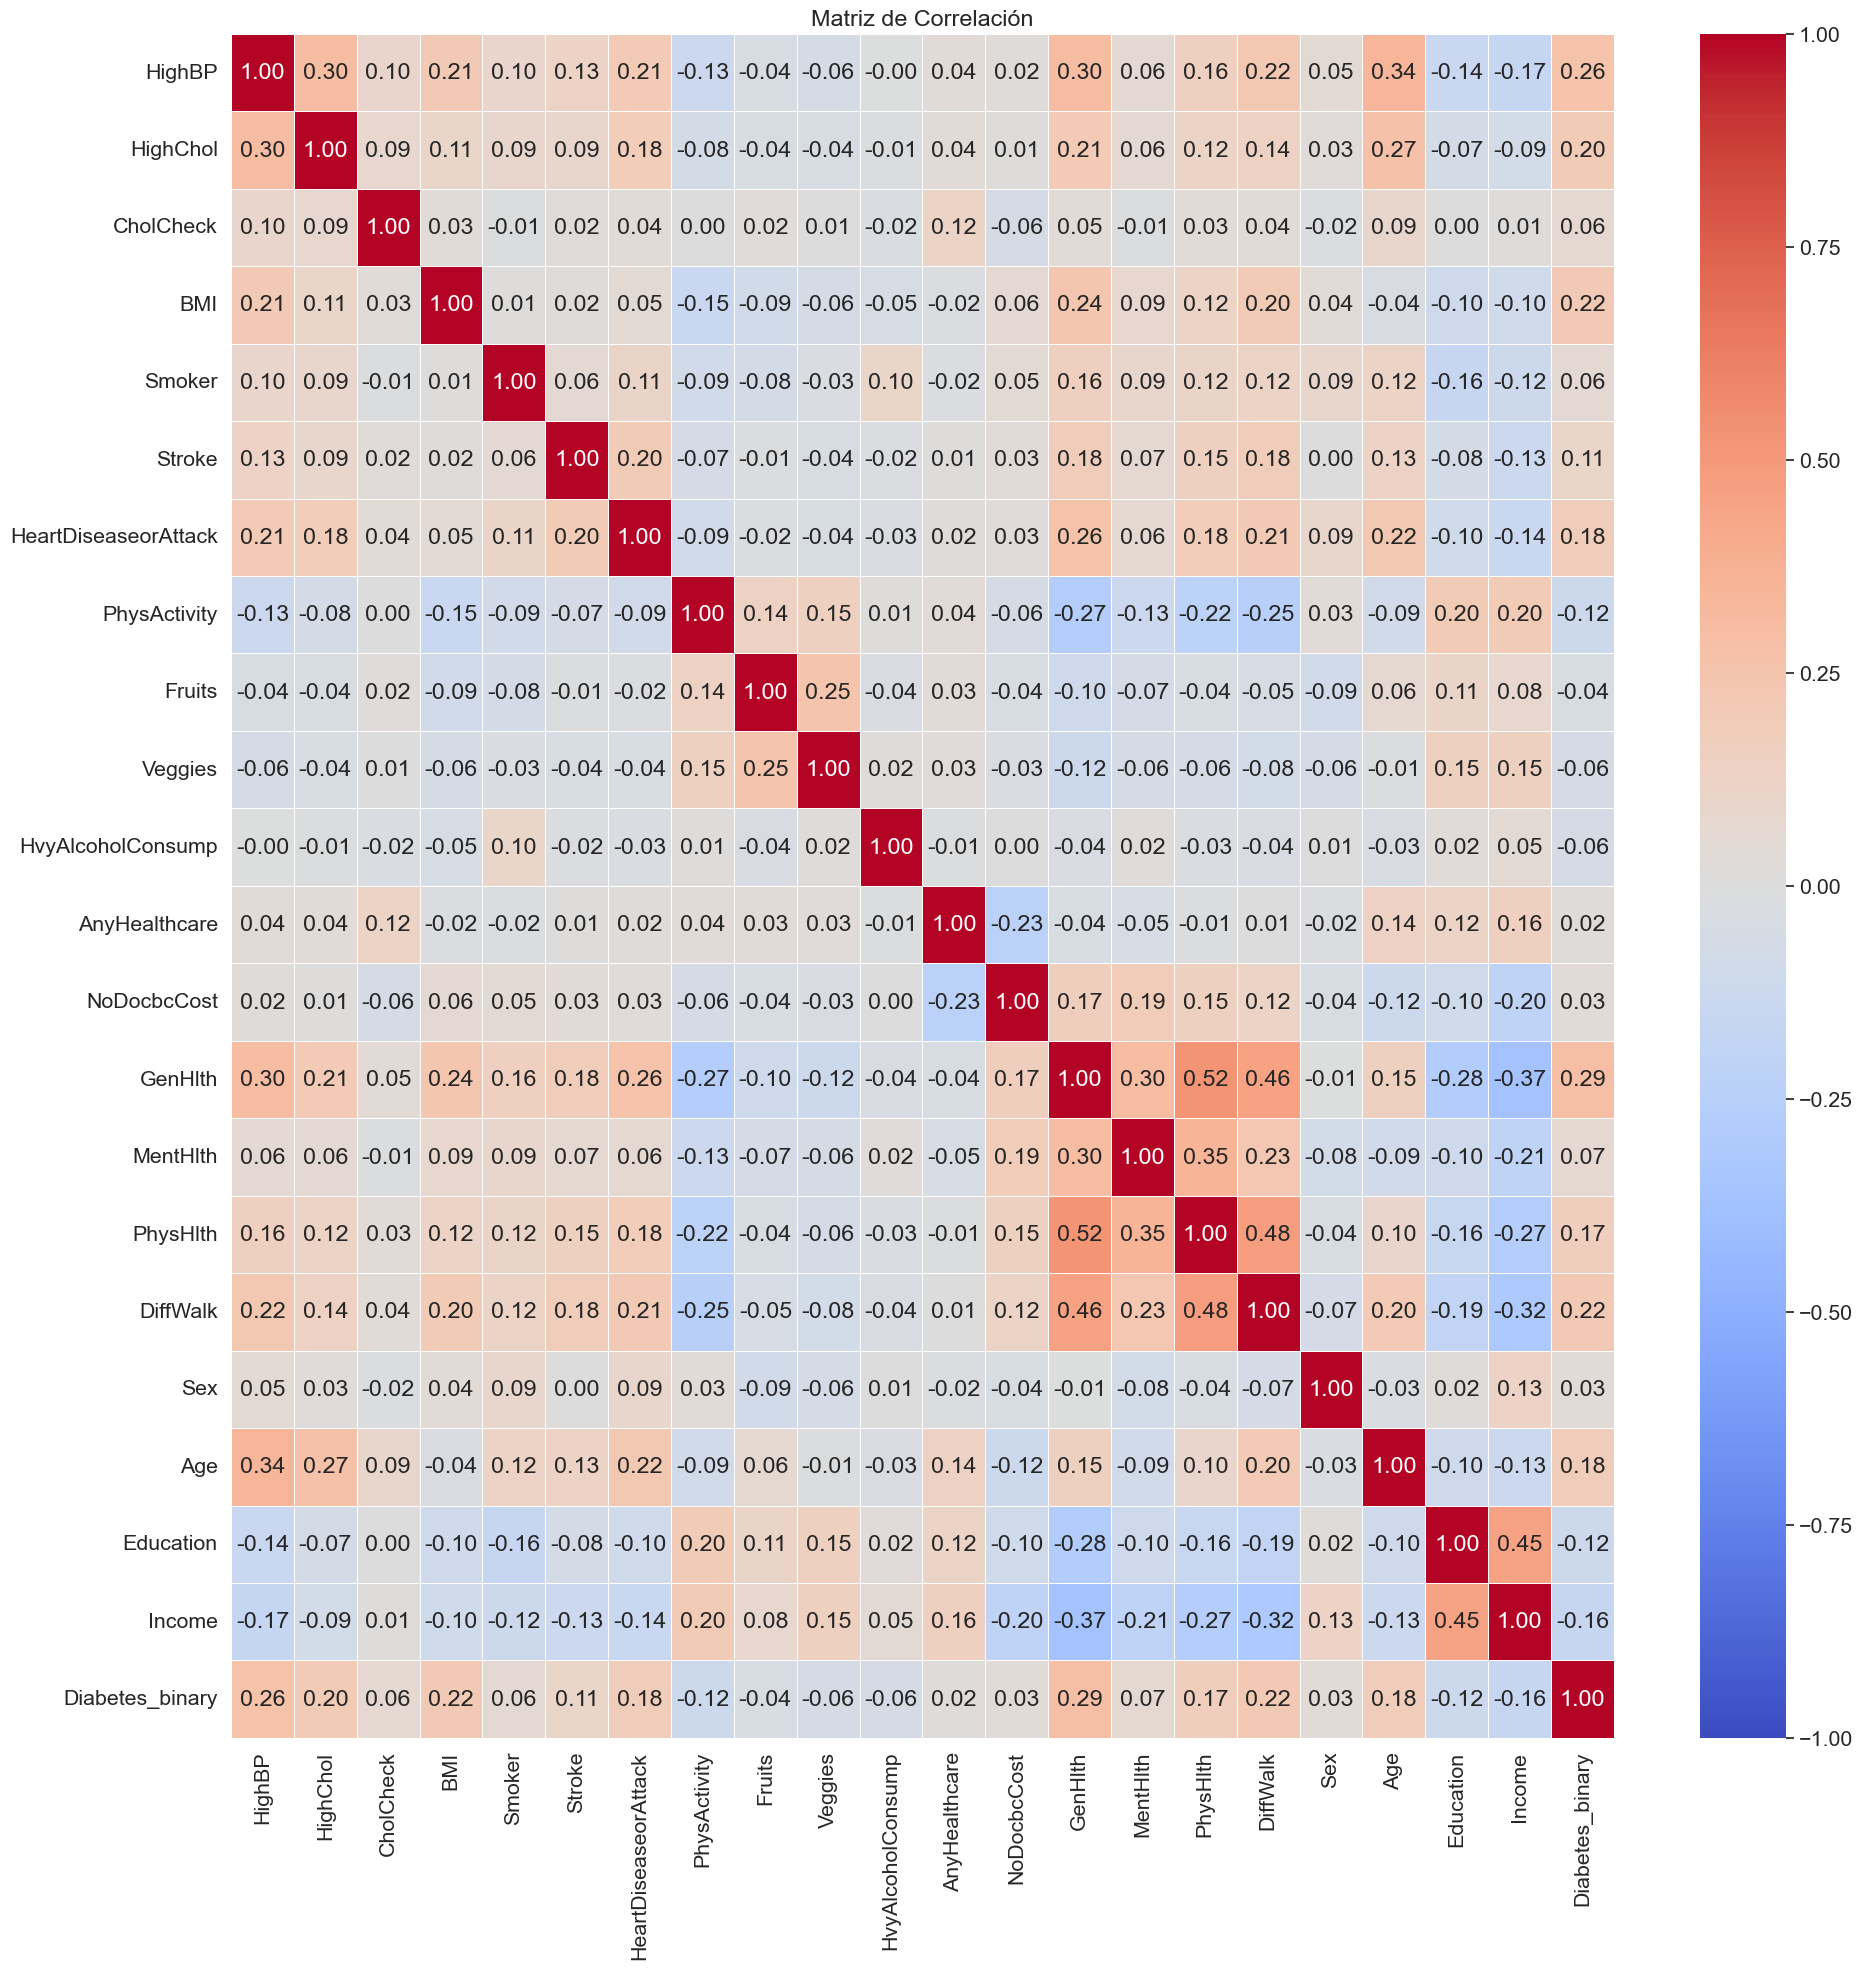

In [20]:
sns.set(font_scale=1.4)
plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          
    cmap="coolwarm",    
    vmin=-1, vmax=1, 
    linewidths=0.5      
)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

**Interpretación:**

El análisis de la matriz de correlación revela patrones clave entre las variables y su asociación con la diabetes (`Diabetes_binary`). Se destacan las siguientes observaciones:

1. Variables con mayor correlación positiva con diabetes:
- Presión arterial alta `HighBP` (0.26) y índice de masa corporal `BMI` (0.22) muestran una asociación moderada pero significativa, lo que sugiere que estos factores están vinculados a un mayor riesgo de diabetes.
- Salud general autopercibida `GenHith` (0.29) y dificultad para caminar `DiffWalk` (0.22) también presentan correlaciones positivas, indicando que un peor estado de salud físico y movilidad reducida pueden estar relacionados con la presencia de diabetes.

2. Variables con correlaciones negativas:
- Actividad física `PhysActivity` (-0.12), nivel educativo `Education` (-0.12) y nivel de ingresos `Income` (-0.16) muestran una relación inversa débil con diabetes, lo que apunta a que estilos de vida más activos, mayores niveles educativos y recursos económicos podrían asociarse a menor prevalencia de la enfermedad.

3. Relaciones entre variables predictoras:
- `GenHith` está fuertemente correlacionada con `PhysHith` 0.52 y `DiffWalk` 0.46, lo que refleja una interconexión entre salud física, movilidad y percepción general de salud.
- `Education` e `Income` presentan una correlación positiva entre sí (0.45), sugiriendo que factores socioeconómicos podrían influir en conjunto en los resultados de salud.

4. Correlaciones débiles o nulas:
- Variables como `AnyHealthcare`, `NoDocbcCost` o `Sex` muestran asociaciones cercanas a cero con diabetes, indicando que su impacto directo es marginal según estos datos.


---

A continuación hallamos el VIF el cual determina la fuerza de la correlación entre las variables independientes. Se pronostica tomando una variable y comparándola con todas las demás. La puntuación VIF de una variable independiente representa hasta qué punto la variable se explica por otras variables independientes.

- Un valor `VIF de 1`: Sin multicolinealidad (variable perfectamente independiente).
- Un valor `VIF entre 1 y 5`: Multicolinealidad baja a moderada (no se considera problemática).
- Un valor `VIF entre 5 y 10`: Multicolinealidad moderada a alta (considerada problemática).
- Un valor `VIF superior a 10`: Multicolinealidad alta (preocupación grave, requiere medidas).

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop = True)
    return(VIF)

VIF_mat = VIF_calculation(X)
display(VIF_mat)

,variable,VIF
0,Education,29.507416
1,CholCheck,23.187436
2,AnyHealthcare,20.839710
3,BMI,18.149913
4,Income,14.156118
5,GenHlth,10.740162
6,Age,9.886830
7,Veggies,5.826886
8,PhysActivity,4.645314
9,Fruits,3.032775


**Interpretación:**

Los valores de VIF obtenidos indican la presencia de multicolinealidad entre las variables predictoras del modelo. Se observa que las variables `Education`, `CholCheck` y `AnyHealthcare` presentan los valores de VIF más elevados (29.51, 23.19 y 20.84, respectivamente), lo que sugiere una fuerte dependencia lineal con otras variables del modelo. Estos resultados superan ampliamente el umbral crítico de `VIF = 5`, e incluso el más estricto de `VIF = 10`, lo que implica que la multicolinealidad podría estar inflando la varianza de los coeficientes de regresión y, por ende, afectando la estabilidad e interpretación del modelo. Variables como `BMI`, `Income` y `GenHlth` también muestran valores preocupantes (18.15, 14.16 y 10.74), aunque en menor grado.

En contraste, las variables restantes (como `Veggies`, `PhysActivity`, `HighBP`, `HighChol` y aquellas con `VIF < 5`) no presentan multicolinealidad significativa, lo que indica que aportan información independiente al modelo. Especialmente, variables como `HvyAlcoholConsump`, `Stroke` y `NoDocbcCost` (`VIF < 1.3`) son prácticamente libres de redundancia.

Estos hallazgos resaltan la necesidad de depurar el modelo para garantizar estimaciones robustas y evitar conclusiones sesgadas.

 ## Modelo de Regresión Lineal 

 Se implementa el modelo de regresión lineal a manera de ejemplo para destacar la importancia que tiene la fase de tratamiento de datos y selección de algoritmos acordes a la naturaleza del problema, en este caso se dividieron en conjuntos de entrenamiento (75%) y prueba (25%) utilizando la función `train_test_split` de scikit-learn. Posteriormente, se entrenó el modelo y se evaluó su rendimiento mediante el coeficiente de determinación 
$R^2$.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Crear y entrenar el modelo de regresión lineal
lr = LinearRegression().fit(X_train, y_train)

# Evaluar el modelo
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(f"Puntuación de entrenamiento: {train_score:.3f}")
print(f"Puntuación de prueba: {test_score:.3f}")

Puntuación de entrenamiento: 0.160
Puntuación de prueba: 0.168


**Interpretación:**

Los resultados obtenidos del modelo de regresión lineal muestran:

- Bajo poder predictivo:
    - El modelo solo explica 16.0% (entrenamiento) y 16.8% (prueba) de la variabilidad de la variable objetivo, lo que indica que el 84% de la variación en los datos no es capturada por las variables predictoras.


- Consistencia entre entrenamiento y prueba:
    - La diferencia mínima entre entrenamiento (16.0%) y prueba (16.8%) sugiere que no hay overfitting, pero el bajo rendimiento en ambos conjuntos indica que el problema radica en la falta de relación lineal o en la calidad de las características.

- Posibles causas:
    - Variables predictoras débiles: Las características utilizadas podrían no tener una relación lineal fuerte con la variable objetivo.
    - Falta de preprocesamiento: Datos no escalados, outliers, desbalances o relaciones no lineales no capturadas.

Los resultados obtenidos demuestran que la regresión lineal no es un modelo adecuado para este caso de estudio, lo cual refuerza la necesidad de emplear modelos más complejos que puedan capturar mejor las relaciones subyacentes en los datos. Este hallazgo también destaca la importancia de seleccionar algoritmos acordes a la naturaleza del problema, priorizando enfoques avanzados cuando sea necesario para mejorar la precisión de las predicciones.

Asimismo, el análisis realizado evidencia el papel fundamental del preprocesamiento y tratamiento de los datos como etapa obligatoria previa a la aplicación de cualquier modelo. Una preparación adecuada de los datos no solo optimiza el rendimiento, sino que también permite extraer conclusiones más confiables.